### ***** Description : ***** 

Ici je créé un script qui va identifier les RBD et créer une colonne debut et fin de RBD en seconde dans mon fichier excel

In [3]:
import re
import math
import numpy as np
import pandas as pd

excel_file = "../data/BDD_RBD_patients.xlsx"
sheet_name = "classification"
df = pd.read_excel(excel_file, sheet_name=sheet_name)

# Afficher les premières lignes d'un DataFrame
df.head()



,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,mouvements,Unnamed: 9,...,Unnamed: 51,Unnamed: 52,manifestations émotionnelles,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,manifestations végétatives,Unnamed: 59,Unnamed: 60
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,type,NaN,...,NaN,NaN,grimace,NaN,NaN,rire,pleurs,modifications respiratoires,sueurs (dermogramme),tachycardie
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evenements élémentaires myocloniques (secousse...,NaN,...,ton autoritaire,soupire/souffle,positive (sourire),negative (fronce sourcil),indeterminée,NaN,NaN,NaN,NaN,NaN
2,NaN,identifiant,Diagnostic,type de mouvements,Durée TCSP,event respiratoire,Nombre d'épisodes RDB,Valence émotionnelle,simples,Majeurs (saccade de l'ensemble du corps),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,X,IB1,PARK,video 1: parle en Arabe ...,1min,apnée obstructive pendant le TCSP,2,negative,0,0,...,0,0,0,1,0,0,0,NaN,NaN,NaN
4,NaN,NaN,NaN,"vidéo 2: rigole x2 et dit ""euh eh""",27s,NaN,NaN,positive,0,0,...,0,0,1,0,0,1,0,NaN,NaN,NaN


In [2]:
import os
import re
from openpyxl import load_workbook

# === Paramètres ===
INPUT_XLSX  = "../data/BDD_RBD_patients.xlsx"
OUTPUT_XLSX = INPUT_XLSX.replace(".xlsx", "") + "_updated.xlsx"
SHEET_NAME  = "classification"

ROW_START = 5  # on commence les données à la ligne 5 

# En-têtes (ligne 4 seulement)
HDR_STUDIED = "Étudié avec Darryl (oui/non)"
HDR_F = "extrait/entier"
HDR_G = "debut_RBD(s)"
HDR_H = "fin_RBD(s)"

# Dossier de référence pour marquer "oui"/"non"
FOLDER_ROOT = "../../documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/"

# === Utilitaires ===
def _to_str(x):
    return "" if x is None else str(x)

def parse_time_like_to_seconds(text):
    """
    Extrait et convertit en secondes la première mention de temps trouvée dans `text`.
    Gère : hh:mm:ss, mm:ss, h/min/s (fr), 'après 15 min', etc. Retourne None si rien.
    """
    if text is None:
        return None
    s = _to_str(text).lower().strip()

    # 1) hh:mm[:ss] ou mm:ss
    m = re.search(r'(\d{1,2}):(\d{1,2})(?::(\d{1,2}))?', s)
    if m:
        g1 = int(m.group(1)); g2 = int(m.group(2)); g3 = int(m.group(3)) if m.group(3) else 0
        return g1*3600 + g2*60 + g3 if m.group(3) is not None else g1*60 + g2

    # 2) unités FR (h/min/s)
    h = mn = sec = None
    mh = re.search(r'(\d+)\s*h(?:eures?)?', s)
    if mh: h = int(mh.group(1))
    mmn = re.search(r'(\d+)\s*(?:min|m)(?![a-z])', s)
    if mmn: mn = int(mmn.group(1))
    ms = re.search(r'(\d+)\s*s(?:ec(?:ondes?)?)?', s)
    if ms: sec = int(ms.group(1))
    if h is not None or mn is not None or sec is not None:
        return (h or 0)*3600 + (mn or 0)*60 + (sec or 0)

    # 3) 'après X ...'
    mapres = re.search(r"apr[eè]s\s+(\d+)\s*(h|heures?|min|m|s|sec(?:ondes?)?)", s)
    if mapres:
        qty = int(mapres.group(1)); unit = mapres.group(2)
        if unit.startswith('h') or unit.startswith('heur'): return qty * 3600
        if unit in ('min', 'm'): return qty * 60
        return qty

    # 4) nombre brut (secondes) si raisonnable (<= 24h)
    try:
        val = float(s.replace(',', '.'))
        if 0 <= val <= 24*3600:
            return val
    except Exception:
        pass
    return None

def contains_video_flag(text):
    return re.search(r'vid[eé]o', _to_str(text).lower()) is not None

# === Prépare la liste des IDs disponibles (noms de dossiers) ===
existing_ids = set()
if os.path.isdir(FOLDER_ROOT):
    for name in os.listdir(FOLDER_ROOT):
        full = os.path.join(FOLDER_ROOT, name)
        if os.path.isdir(full):
            existing_ids.add(str(name).strip())
else:
    print(f">>> Dossier introuvable : {FOLDER_ROOT} - les lignes avec identifiant seront marquées 'non'.")

print(f'Liste des identifiants existants ({len(existing_ids)} trouvés) : {sorted(existing_ids)}')

# === Ouvrir et modifier la feuille ===
wb = load_workbook(INPUT_XLSX)
ws = wb[SHEET_NAME] if SHEET_NAME else wb.active
max_row = ws.max_row

# --- 1) Insérer la colonne "Étudié..." AVANT la colonne Identifiant (on suppose Identifiant initialement en B) ---
# Pour être robuste, on cherche la colonne 'Identifiant' en ligne 4 ; sinon on assume B (col=2).
ident_col_idx = 2
for c in range(1, ws.max_column + 1):
    if _to_str(ws.cell(row=4, column=c).value).strip().lower() == "identifiant":
        ident_col_idx = c
        break

# Si l'en-tête HDR_STUDIED n'est pas déjà juste avant 'Identifiant', on insère 1 colonne à ident_col_idx
if _to_str(ws.cell(row=4, column=ident_col_idx - 1).value).strip().lower() != HDR_STUDIED.lower():
    ws.insert_cols(ident_col_idx)
    # après insertion, Identifiant est décalé d'1 vers la droite, et la nouvelle colonne est à ident_col_idx
else:
    # La colonne existe déjà ; on ne réinsère pas.
    pass

# Écrire l’en-tête en ligne 4 uniquement (ne rien toucher en 1-3)
studied_col_idx = ident_col_idx  # position de la colonne insérée
ws.cell(row=4, column=studied_col_idx, value=HDR_STUDIED)

# L'identifiant est maintenant en (ident_col_idx + 1)
ident_data_col = ident_col_idx + 1

# Remplir la colonne "Étudié..." à partir de la ligne 5 ; si ID vide -> SKIP (laisse vide)
for r in range(ROW_START, max_row + 1):
    id_val = _to_str(ws.cell(row=r, column=ident_data_col).value).strip()
    if id_val == "":
        studied = None  # skip si identifiant vide
    else:
        studied = "oui" if id_val in existing_ids else "non"
    ws.cell(row=r, column=studied_col_idx, value=studied)

print(f"Nombre d'identifiants marqués 'oui' : {sum(1 for r in range(ROW_START, max_row + 1) if _to_str(ws.cell(row=r, column=studied_col_idx).value).strip().lower() == 'oui')}")
print(f"Liste des identifiant marqués 'oui' : {[ _to_str(ws.cell(row=r, column=ident_data_col).value).strip() for r in range(ROW_START, max_row + 1) if _to_str(ws.cell(row=r, column=studied_col_idx).value).strip().lower() == 'oui' ]}")

# On compare avec le nombre total d'IDs existants et on avertit si certains manquent
count_oui = sum(1 for r in range(ROW_START, max_row + 1) if _to_str(ws.cell(row=r, column=studied_col_idx).value).strip().lower() == 'oui')
if count_oui < len(existing_ids):
    print(f">>> Attention : {len(existing_ids) - count_oui} identifiants existants n'ont pas été marqués 'oui' dans la feuille.")
    # On peut lister ceux manquants :
    marked_ids = set(_to_str(ws.cell(row=r, column=ident_data_col).value).strip() for r in range(ROW_START, max_row + 1) if _to_str(ws.cell(row=r, column=studied_col_idx).value).strip().lower() == 'oui')
    missing_ids = existing_ids - marked_ids
    print(f">>> Identifiants manquants : {sorted(missing_ids)}")
    

# --- 2) Ajouter/mettre à jour les colonnes F-H (extrait/début/fin) en préservant fusions ---
# Après l'insertion d'une colonne avant Identifiant, les index colonnes d'origine sont décalés.
# Si, à l'origine, D=4 et E=5, et qu'on a inséré une colonne avant B (col=2) ou juste avant 'Identifiant',
# alors D -> D+1 et E -> E+1. On fixe D_idx et E_idx *après* notre insertion.
D_idx = 5  # D original + 1
E_idx = 6  # E original + 1

# On veut insérer 3 colonnes juste après E => à partir de (E_idx + 1)
insert_after_E_idx = E_idx + 1  # première nouvelle colonne (ex-HDR_F)

# Si les en-têtes attendus ne sont pas déjà posés en ligne 4, on insère 3 colonnes
already_ok = (
    _to_str(ws.cell(row=4, column=insert_after_E_idx).value).strip().lower() == HDR_F.lower() and
    _to_str(ws.cell(row=4, column=insert_after_E_idx+1).value).strip().lower() == HDR_G.lower() and
    _to_str(ws.cell(row=4, column=insert_after_E_idx+2).value).strip().lower() == HDR_H.lower()
)
if not already_ok:
    ws.insert_cols(insert_after_E_idx, amount=3)

# Écrire les en-têtes en ligne 4 (ne rien écrire en 1-3)
ws.cell(row=4, column=insert_after_E_idx,     value=HDR_F)
ws.cell(row=4, column=insert_after_E_idx + 1, value=HDR_G)
ws.cell(row=4, column=insert_after_E_idx + 2, value=HDR_H)

# Remplir valeurs à partir de ROW_START, en propageant le label extrait/entier quand Identifiant est vide
last_label_for_patient = None
for r in range(ROW_START, max_row + 1):
    colD = ws.cell(row=r, column=D_idx).value
    colE = ws.cell(row=r, column=E_idx).value
    id_val = _to_str(ws.cell(row=r, column=ident_data_col).value).strip()

    if id_val != "":
        last_label_for_patient = "extrait" if contains_video_flag(colD) else "entier"
        label = last_label_for_patient
    else:
        label = last_label_for_patient if last_label_for_patient is not None else ("extrait" if contains_video_flag(colD) else "entier")

    debut_s = parse_time_like_to_seconds(colD)
    duree_s = parse_time_like_to_seconds(colE)
    fin_s   = (debut_s + duree_s) if (debut_s is not None and duree_s is not None) else None

    ws.cell(row=r, column=insert_after_E_idx,     value=label)
    ws.cell(row=r, column=insert_after_E_idx + 1, value=debut_s)
    ws.cell(row=r, column=insert_after_E_idx + 2, value=fin_s)

# --- Sauvegarde ---
wb.save(OUTPUT_XLSX)
print(f">>> Terminé. Fichier écrit : {OUTPUT_XLSX}")


Liste des identifiants existants (76 trouvés) : ['AE129', 'AN166', 'BA152', 'BA171', 'BB114', 'BDRE44', 'BF181', 'BJ138', 'BO60', 'CA169', 'CB165', 'CC175', 'CD164', 'CD28', 'CJL159', 'CJP53', 'CM161', 'CP155', 'CS131', 'CS147', 'DA110', 'DA174', 'DI136', 'DJ137', 'DSJ112', 'EF130', 'FP144', 'GD170', 'GH163', 'GR108', 'GS191', 'GX111', 'HG167', 'IS179', 'JB173', 'JLJ177', 'JP141', 'KH113', 'LF126', 'LJ41', 'LS162', 'MA27', 'MC154', 'MFJ160', 'MG16', 'MHTK39', 'ML135', 'MM109', 'MN143', 'MN26', 'MP150', 'MRM132', 'MS128', 'NAL43', 'NGA157', 'PA139', 'PF133', 'PJC140', 'PJL153', 'RB103', 'RD158', 'RG156', 'RH146', 'RJ42', 'RJP148', 'SB176', 'SB178', 'SD134', 'SJP172', 'TJ127', 'TLM168', 'TM142', 'TM151', 'TO145', 'VA182', 'VJ149']
Nombre d'identifiants marqués 'oui' : 59
Liste des identifiant marqués 'oui' : ['MG16', 'MN26', 'MA27', 'CD28', 'MHTK39', 'LJ41', 'RJ42', 'NAL43', 'BDRE44', 'CJP53', 'BO60', 'RB103', 'GR108', 'MM109', 'DA110', 'GX111', 'DSJ112', 'KH113', 'BB114', 'LF126', 'TJ12

## ***** Analysons l'amplitude de mes signaux EMG sur ces fenêtres *****

## 1 - Visu

Opening raw data file /home/darryld/documents/EEG/preprocessed/bipolaire/2_rem_only/gp2/BB114/BB114_annotated_150.fif...
    Range : 0 ... 7678719 =      0.000 ... 29994.996 secs
Ready.


/tmp/ipykernel_3549365/561131413.py:7: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/2_rem_only/gp2/BB114/BB114_annotated_150.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(file_path, preload=True)


Reading 0 ... 7678719  =      0.000 ... 29994.996 secs...


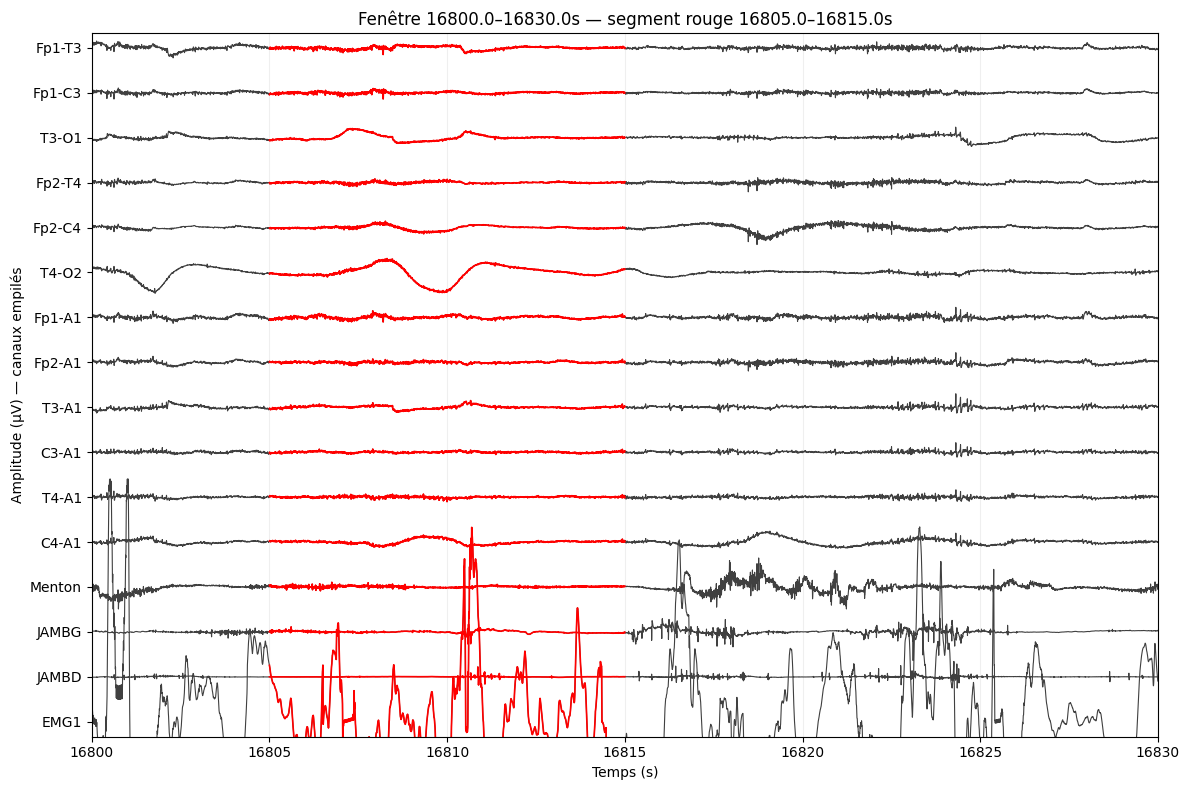

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# --- Chemins & chargement ---
file_path = "/home/darryld/documents/EEG/preprocessed/bipolaire/2_rem_only/gp2/BB114/BB114_annotated_150.fif"
raw = mne.io.read_raw_fif(file_path, preload=True)

# --- Paramètres d'affichage ---
page_sec = 30.0             # durée de la "page" affichée (style polysomnographie)
page_start = 16800.0        # début de la page (en s, à adapter)
highlight_dur = 10.0        # durée de la portion à colorer en rouge (s)
highlight_start = page_start + 5.0  # début de la portion rouge à l'intérieur de la page

picks = mne.pick_types(raw.info, eeg=True, eog=True, emg=True)  # adapte (eeg/eog/emg)
max_channels = 16            # nombre de canaux à afficher
picks = picks[:max_channels]

# --- Extraction des données de la page ---
sfreq = raw.info['sfreq']
i0 = int((page_start - raw.first_time) * sfreq)
i1 = int(((page_start + page_sec) - raw.first_time) * sfreq)
i0 = max(i0, 0); i1 = min(i1, raw.n_times)

data, times = raw.get_data(picks=picks, start=i0, stop=i1, return_times=True)

# --- Mise à l'échelle (en µV) et centrage par canal pour une belle pile ---
data = data * 1e6  # V -> µV
data = data - np.median(data, axis=1, keepdims=True)

# --- Décimation légère pour l'affichage (facultatif) ---
target_pts = 6000
decim = max(1, data.shape[1] // target_pts)
data = data[:, ::decim]
times = times[::decim]

# --- Masque temporel pour le segment rouge ---
mask = (times >= highlight_start) & (times <= (highlight_start + highlight_dur))

# --- Construction de la pile avec espacement ---
spacing = np.nanpercentile(np.abs(data), 95)  # espacement empirique
offsets = np.arange(len(picks))[::-1] * (spacing * 3.0)  # 3x pour éviter le chevauchement
data_stack = data + offsets[:, None]

# --- Tracé ---
fig, ax = plt.subplots(figsize=(12, 8))

# Traces grises (toute la page)
for ch_idx in range(len(picks)):
    ax.plot(times, data_stack[ch_idx], lw=0.8, color='0.25')

# Portion rouge (même signal mais uniquement sur le masque)
for ch_idx in range(len(picks)):
    y = data_stack[ch_idx].copy()
    y[~mask] = np.nan  # NaN -> segments interrompus hors fenêtre
    ax.plot(times, y, lw=1.2, color='red')

# Cosmétiques
ax.set_xlim(page_start, page_start + page_sec)
ax.set_ylim(offsets[-1] - spacing, offsets[0] + spacing)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Amplitude (µV) - canaux empilés")
ax.set_title(f"Fenêtre {page_start:.1f}-{page_start+page_sec:.1f}s - segment rouge {highlight_start:.1f}-{(highlight_start+highlight_dur):.1f}s")

# Étiquettes des canaux sur l'axe Y
ax.set_yticks(offsets)
ax.set_yticklabels([raw.ch_names[p] for p in picks])

# Optionnel : bandeau de fond pour repérer visuellement la zone rouge
#ax.axvspan(highlight_start, highlight_start + highlight_dur, alpha=0.12, color='red', zorder=0)

ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()


## 2 - Détection RBD manuelle

#### 2.1 - Dictionnaire pour chaque patient avec les fenêtres RBD identifiées visuellement

In [1]:
import os
import pandas as pd
from collections import defaultdict

# ----- Paramètres -----
EXCEL_PATH = "../data/BDD_RBD_patients_classif_updated_VF.xlsx"
SHEET_NAME = "classification"
HEADER_ROW = 3   # ligne 4 dans Excel

# Noms de colonnes attendues (tels qu’en ligne 4)
COL_ID      = "identifiant"
COL_STUDIED = "Étudié avec Darryl (oui/non)"
COL_DEBUT   = "debut_RBD(s)"
COL_FIN     = "fin_RBD(s)"
COL_LABEL   = "extrait/entier"
COL_DESC    = "type de mouvements "

# Répertoire des patients étudiés (dossiers gp2)
GP2_DIR = "../../documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/"

# ----- Lecture -----
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, header=HEADER_ROW)

# Vérifs minimales
for c in [COL_ID, COL_STUDIED, COL_DEBUT, COL_FIN]:
    if c not in df.columns:
        raise ValueError(f"Colonne manquante dans l'Excel: {c!r}")

# ----- Liste "stricte" des patients depuis gp2 (exact match, sensible à la casse) -----
if not os.path.isdir(GP2_DIR):
    raise FileNotFoundError(f"Répertoire introuvable: {GP2_DIR}")

patients_gp2 = {name.strip() for name in os.listdir(GP2_DIR) if os.path.isdir(os.path.join(GP2_DIR, name))}
print(f"Dossiers patients trouvés sur le Serveur: {len(patients_gp2)}")

# ----- Préparation des données Excel -----
# On propage l'ID et 'Étudié...' pour capturer les lignes de continuation (ID vide)
df["__id_ffill"] = df[COL_ID].ffill()
df["__studied_ffill"] = df[COL_STUDIED].ffill()

# Normalisations utiles
df["__id_ffill"] = df["__id_ffill"].astype(str).str.strip()
df["__studied_ffill_norm"] = df["__studied_ffill"].astype(str).str.strip().str.lower()

# Filtre: patients étudiés = 'oui' (après propagation)
mask_studied = df["__studied_ffill_norm"].eq("oui")
mask_times   = df[COL_DEBUT].notna() & df[COL_FIN].notna()

# On garde seulement les lignes avec temps renseignés et étudié=oui
sub = df.loc[mask_studied & mask_times].copy()

# Conversion sûre en float (secondes)
sub[COL_DEBUT] = pd.to_numeric(sub[COL_DEBUT], errors="coerce")
sub[COL_FIN]   = pd.to_numeric(sub[COL_FIN], errors="coerce")
sub = sub.loc[sub[COL_DEBUT].notna() & sub[COL_FIN].notna() & (sub[COL_FIN] > sub[COL_DEBUT])].copy()

# ----- Sélection stricte: l'ID doit correspondre à un dossier présent dans gp2 -----
# (Comparaison stricte: sensible à la casse ; on enlève juste les espaces de bord)
sub["__id_ffill"] = sub["__id_ffill"].astype(str).str.strip()
sub = sub[sub["__id_ffill"].isin(patients_gp2)].copy()

# ----- Construction du dictionnaire -----
windows_by_patient = defaultdict(list)

for _, row in sub.iterrows():
    pid = row["__id_ffill"]

    # Description nettoyée (retire ":" et tokens purement numériques)
    desc = row[COL_DESC] if (COL_DESC in sub.columns) else None
    if isinstance(desc, str):
        desc = desc.replace(":", "").strip()
        desc = " ".join(tok for tok in desc.split() if not tok.isdigit())

    label = row[COL_LABEL] if (COL_LABEL in sub.columns) else None

    windows_by_patient[pid].append({
        "start": float(row[COL_DEBUT]),
        "end": float(row[COL_FIN]),
        "duration(s)": float(row[COL_FIN] - row[COL_DEBUT]),
        "description": desc,
        "extrait/entier": label,
    })

# Tri des fenêtres par début
for pid in list(windows_by_patient.keys()):
    windows_by_patient[pid].sort(key=lambda d: d["start"])

# ----- Diagnostics -----
# Patients marqués "oui" (après ffill) présents dans le classeur
ids_yes_in_excel = set(df.loc[df["__studied_ffill_norm"].eq("oui"), "__id_ffill"].astype(str).str.strip().unique())
ids_yes_in_excel.discard("")  # au cas où

# Intersection stricte avec gp2
ids_yes_and_in_gp2 = sorted(id_ for id_ in ids_yes_in_excel if id_ in patients_gp2)
ids_final = sorted(windows_by_patient.keys())

print(f"\nPatients 'oui' détectés dans l'Excel: {len(ids_yes_in_excel)}")
print(f"Patients 'oui' qui existent sur le serveur: {len(ids_yes_and_in_gp2)}")
print(f"Total de fenêtres RBD collectées: {sum(len(v) for v in windows_by_patient.values())}")

# Patients 'oui' présents dans gp2 mais sans fenêtre valide
missing_windows = sorted(set(ids_yes_and_in_gp2) - set(ids_final))
if missing_windows:
    print("\nPatients 'oui' présents sur le serveur mais SANS fenêtre valide:")
    for pid in missing_windows[:50]:
        print("  -", pid)
    if len(missing_windows) > 50:
        print(f"  ... (+{len(missing_windows)-50} autres)")

# Exemples d'aperçu
if ids_final[:5]:
    print("\nExemples (jusqu'à 5 IDs):", ids_final[:5])
    for pid in ids_final[:3]:
        print(f"\nPatient {pid}:")
        for win in windows_by_patient[pid][:100]:
            print("  -", win)

# Enregistrer `windows_by_patient` au format csv
import csv
csv_output_path = "../data/windows_by_patient.csv"
with open(csv_output_path, mode='w', newline='') as csvfile:
    fieldnames = ['patient_id', 'start', 'end', 'duration(s)', 'description', 'extrait/entier']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    for pid, windows in windows_by_patient.items():
        for win in windows:
            row = {'patient_id': pid}
            row.update(win)
            writer.writerow(row)
print(f"\n>>> `windows_by_patient` enregistré au format CSV : {csv_output_path}")

Dossiers patients trouvés sur le Serveur: 76

Patients 'oui' détectés dans l'Excel: 66
Patients 'oui' qui existent sur le serveur: 57
Total de fenêtres RBD collectées: 443

Patients 'oui' présents sur le serveur mais SANS fenêtre valide:
  - BDRE44
  - GX111
  - LF126
  - LJ41
  - MN26
  - RJ42

Exemples (jusqu'à 5 IDs): ['AE129', 'BA152', 'BA171', 'BB114', 'BF181']

Patient AE129:
  - {'start': 4323.0, 'end': 4350.0, 'duration(s)': 27.0, 'description': 'mvt de la tête, bruit bizarre de la bouche en levant la main gauche', 'extrait/entier': 'entier'}
  - {'start': 4833.0, 'end': 4862.0, 'duration(s)': 29.0, 'description': 'mvt très restreints myocloniques répétés des mains et des jambes. Souffle à', 'extrait/entier': 'entier'}
  - {'start': 5888.0, 'end': 5904.0, 'duration(s)': 16.0, 'description': 'lève la tête , bouge la main gauche (doigts) et les jambes', 'extrait/entier': 'entier'}

Patient BA152:
  - {'start': 6526.0, 'end': 6620.0, 'duration(s)': 94.0, 'description': 'gémit et m

#### 2.2 - Mise en évidence des RBD identifiés manuellement

Patient: EF130 | Fenêtres RBD: 2 | REM: 8 (époque=30s)


/tmp/ipykernel_3470929/1747882422.py:113: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


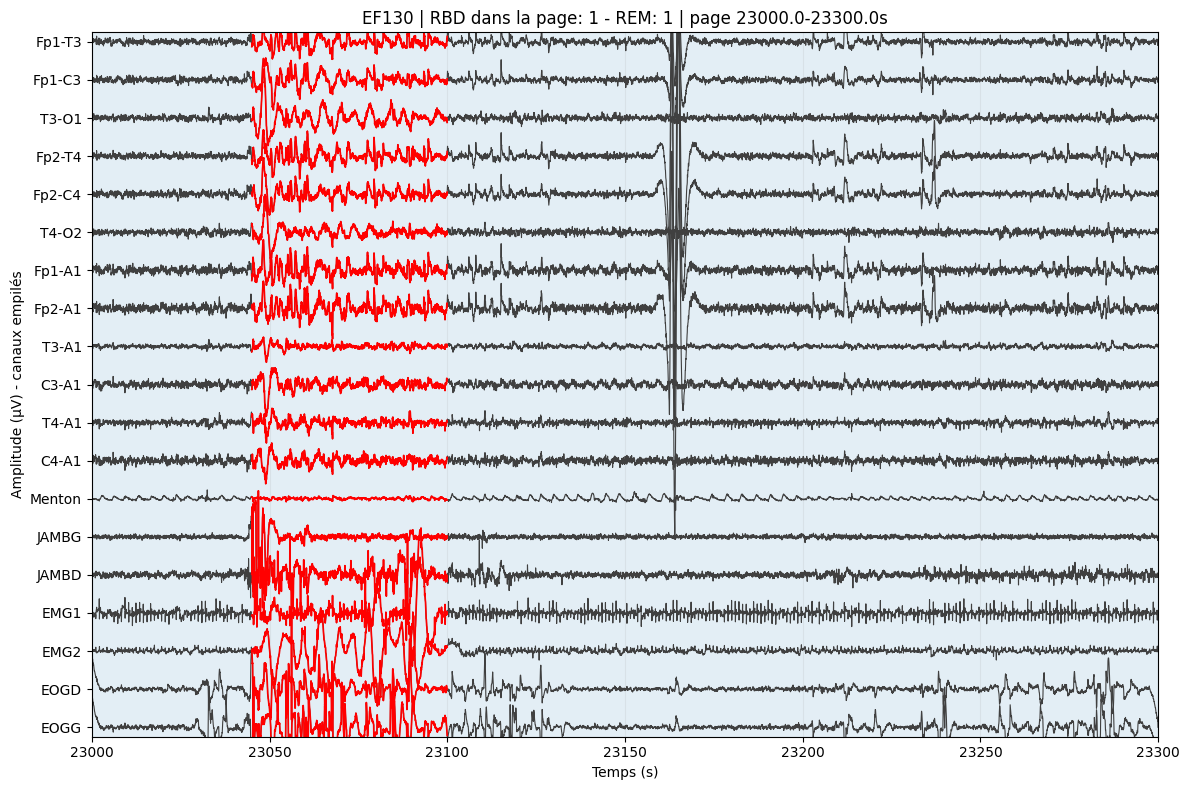

In [ ]:
# === À coller dans une cellule ===
import os
from pathlib import Path
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# ========= Paramètres =========
hypno_path = "/home/darryld/documents/EEG/raw/EF130/EF130_hypnoEXP.txt"
fif_file   = "/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_art_annotated.fif"

SHOW_REM_SHADE = True
HYPNO_OFFSET_S = 0.0         # décalage des REM si besoin

# Affichage "page"
page_sec   = 300.0
page_start = 23450.0
max_channels = 20
DECIM_TARGET_PTS = 6000
PICK_EEG, PICK_EOG, PICK_EMG = True, True, True

# GAIN VISUEL des canaux EMG (insensible à la casse, match par inclusion)
# Exemple: 0.5 pour diviser par 2, 2.0 pour doubler l’amplitude
EMG_GAINS = {"EMG1": 2.0, "EMG2": 2.0, "JAMBG": 10.0, "JAMBD": 10.0}

# ========= Utilitaires =========
def extract_patient_id_from_path(fpath: str) -> str:
    p = Path(fpath).resolve()
    parts = list(p.parts)
    for i, seg in enumerate(parts):
        if seg.lower() == "gp2" and i + 1 < len(parts):
            return parts[i + 1]
    return p.parent.name  # fallback

def build_union_mask(times: np.ndarray, intervals):
    mask = np.zeros_like(times, dtype=bool)
    for (a, b) in intervals:
        if b > a:
            mask |= (times >= a) & (times < b)
    return mask

def read_hypnogram_intervals_rem(path):
    """
    Hypnogramme texte colonnes:
        0: temps cumulé en secondes (fin d'époque)
        1: HH:MM:SS (ignoré)
        2: stade: 'W','N1','N2','N3','R','REM', etc.
        3: optionnelle (ignorée)
    Retourne rem_intervals (start_s, end_s) fusionnés et epoch_len (s).
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Hypnogramme introuvable: {path}")

    df = pd.read_csv(
        path,
        sep=r"\s+",
        engine="python",
        header=None,
        comment="#",
        names=["t_end_s", "hhmmss", "stage", "extra"],
        usecols=[0, 1, 2],
        dtype={0: float, 1: str, 2: str},
        encoding_errors="ignore"
    )

    df = df.dropna(subset=["t_end_s", "stage"]).copy()
    df["stage"] = df["stage"].astype(str).str.strip().str.upper()

    diffs = np.diff(df["t_end_s"].to_numpy())
    epoch_len = float(pd.Series(np.round(diffs, 1)).mode().iloc[0]) if diffs.size else 30.0

    # Fusion des époques contiguës en REM
    is_rem = df["stage"].isin(["R", "REM"])
    rem_intervals, run_start, prev_end = [], None, None
    for t_end, flag in zip(df["t_end_s"], is_rem):
        t_start = t_end - epoch_len
        if flag:
            if run_start is None:
                run_start = t_start
            prev_end = t_end
        else:
            if run_start is not None:
                rem_intervals.append((float(run_start), float(prev_end)))
                run_start, prev_end = None, None
    if run_start is not None and prev_end is not None:
        rem_intervals.append((float(run_start), float(prev_end)))

    return rem_intervals, epoch_len


# ========= 1) Récup fenêtres RBD depuis windows_by_patient =========
if 'windows_by_patient' not in globals():
    raise RuntimeError("Le dict 'windows_by_patient' est introuvable. Exécute d'abord la cellule qui le construit.")

patient_id = extract_patient_id_from_path(fif_file)
wins = windows_by_patient.get(patient_id, [])
if not wins:
    print(f" Aucune fenêtre RBD pour {patient_id} dans 'windows_by_patient'.")

# Intervalles RBD (start, end) pour masquage rouge
rbd_intervals = [(float(w['start']), float(w['end'])) for w in wins if ('start' in w and 'end' in w)]

# ========= 2) (Optionnel) Intervalles REM pour ombrage de fond =========
rem_intervals, epoch_len = [], 30.0
if SHOW_REM_SHADE and hypno_path and os.path.isfile(hypno_path):
    rem_intervals, epoch_len = read_hypnogram_intervals_rem(hypno_path)
    if HYPNO_OFFSET_S:
        rem_intervals = [(a + HYPNO_OFFSET_S, b + HYPNO_OFFSET_S) for (a, b) in rem_intervals]
print(f"Patient: {patient_id} | Fenêtres RBD: {len(rbd_intervals)} | REM: {len(rem_intervals)} (époque={epoch_len:.0f}s)")

# ========= 3) Charger le FIF =========
raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
sfreq = raw.info["sfreq"]

# ========= 4) Choix canaux & page =========
picks = mne.pick_types(raw.info, meg=False, eeg=PICK_EEG, eog=PICK_EOG, emg=PICK_EMG, stim=False, misc=False)
picks = picks[:max_channels]
if len(picks) == 0:
    raise RuntimeError("Aucun canal sélectionné (vérifie PICK_EEG/EOG/EMG).")

i0 = int((page_start - raw.first_time) * sfreq)
i1 = int(((page_start + page_sec) - raw.first_time) * sfreq)
i0 = max(i0, 0); i1 = min(i1, raw.n_times)

data, times = raw.get_data(picks=picks, start=i0, stop=i1, return_times=True)
data = data * 1e6
data = data - np.median(data, axis=1, keepdims=True)

# -------- Filtre EOG AVANT décimation (évite l'aliasing) --------
eog_picks_all = mne.pick_types(raw.info, meg=False, eeg=False, eog=True, emg=False, stim=False, misc=False)
# indices des EOG parmi les 'picks' affichés
eog_in_picks = [np.where(picks == ep)[0][0] for ep in eog_picks_all if ep in picks]
if eog_in_picks:
    data[eog_in_picks, :] = mne.filter.filter_data(
        data=data[eog_in_picks, :],
        sfreq=sfreq,     # fréquence d'échantillonnage AVANT décimation
        l_freq=0.3,
        h_freq=10.0,    
        verbose=False
    )

# -------- Décimation pour affichage --------
decim = max(1, data.shape[1] // DECIM_TARGET_PTS)
if decim > 1:
    data = data[:, ::decim]
    times = times[::decim]

# Appliquer les gains visuels sur EMG1/EMG2 (après décimation, avant empilement)
if EMG_GAINS:
    ch_names = [raw.ch_names[p] for p in picks]
    scale = np.ones(len(picks), dtype=float)
    # match insensible à la casse et par inclusion du nom demandé
    for i, nm in enumerate(ch_names):
        low = nm.lower()
        for key, gain in EMG_GAINS.items():
            if key.lower() in low:
                scale[i] = float(gain)
                break
    data = data * scale[:, None]

# Intersections avec la page
page_a, page_b = page_start, page_start + page_sec
def clip_to_page(intervals):
    out = []
    for a, b in intervals:
        aa, bb = max(a, page_a), min(b, page_b)
        if bb > aa:
            out.append((aa, bb))
    return out

rbd_in_page = clip_to_page(rbd_intervals)
rem_in_page = clip_to_page(rem_intervals)

mask_rbd = build_union_mask(times, rbd_in_page)
mask_rem = build_union_mask(times, rem_in_page)

# ========= 5) Tracé (gris + RBD rouge + REM ombré) =========
# Espacement calculé sur l'ensemble (calcule sur EEG uniquement possible si besoin)
spacing = np.nanpercentile(np.abs(data), 95) if data.size else 1.0
spacing = spacing if spacing > 0 else 1.0
offsets = np.arange(len(picks))[::-1] * (spacing * 4.0)
data_stack = data + offsets[:, None]

fig, ax = plt.subplots(figsize=(12, 8))

# Ombre REM en fond (bleu clair)
for (aa, bb) in rem_in_page:
    ax.axvspan(aa, bb, alpha=0.12)

# Signaux en gris
for ch_idx in range(len(picks)):
    ax.plot(times, data_stack[ch_idx], lw=0.8, color='0.25')

# Segments RBD en ROUGE (depuis windows_by_patient)
if mask_rbd.any():
    for ch_idx in range(len(picks)):
        y = data_stack[ch_idx].copy()
        y[~mask_rbd] = np.nan
        ax.plot(times, y, lw=1.2, color='red')

# Axes & titres
ax.set_xlim(page_a, page_b)
ax.set_ylim(offsets[-1] - spacing, offsets[0] + spacing)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Amplitude (µV) - canaux empilés")
ax.set_title(f"{patient_id} | RBD dans la page: {len(rbd_in_page)} - REM: {len(rem_in_page)} | page {page_a:.1f}-{page_b:.1f}s")

ax.set_yticks(offsets)
ax.set_yticklabels([raw.ch_names[p] for p in picks])
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()


## 3- Méthode semi-automatique de quantification du RSWA
*(d’après Possti et al., NPJ Digital Medicine, 2024)*

La méthode semi-automatique de détection du **REM Sleep Without Atonia (RSWA)** repose sur l’analyse du signal **EMG mentonnier** pendant le sommeil paradoxal (REM).  
Elle vise à quantifier automatiquement l’activité musculaire anormale tout en s’appuyant sur un staging REM manuel.

---

### Étape 1 - Prétraitement du signal EMG

Le signal EMG du menton est filtré avec :
- un **passe-haut à 30 Hz** pour éliminer les composantes basses (mouvements, respiration),
- un **notch à 50 Hz** (Q = 30) pour supprimer le bruit secteur,
- un **passe-bas à 100 Hz** .

L’échantillonnage est ramené à **500 Hz**.  
L’analyse est limitée aux **époques identifiées comme REM** (30s).

---

### Étape 2 - Calcul du MAAV (Mean Absolute Amplitude Value)

Le signal filtré est découpé en fenêtres de **0,1 s** avec **50 % de recouvrement**.

Pour chaque fenêtre, on calcule :

$
\mathrm{MAAV} = \frac{1}{N}\sum_{i=1}^{N} \lvert x_i \rvert
$

où \(x_i\) est l’amplitude du signal EMG dans la fenêtre.

Le vecteur MAAV représente l’enveloppe moyenne du signal EMG.

Deux **tests de normalité de Shapiro-Wilk** sont effectués :
1. sur le signal EMG filtré,
2. sur le vecteur MAAV.

Si les deux statistiques dépassent les seuils (0.95 et 0.9), l’époque REM est considérée **sans activité EMG** et exclue.

---

### Étape 3 - Détection adaptative des segments actifs (=Artéfacts)

Un **seuil adaptatif** est défini au **55ᵉ percentile du MAAV** de chaque époque REM.  
Les segments où le MAAV dépasse ce seuil sont considérés comme **potentiellement actifs**.

Pour chaque segment, les critères suivants sont évalués :

| Caractéristique         | Condition d’activation                    |
|--------------------------|------------------------------------------|
| Fréquence médiane        | < 115 Hz                                 |
| RMS                      | > 2 × seuil MAAV                         |
| Taux de passage par zéro | > 140                                    |
| Pics FFT                 | ≠ harmoniques du 50 Hz                   |

Les segments validés sur ces quatre critères sont retenus comme **bursts EMG réels**.  
Les segment non-validés sont considérés comme des artefacts.  
*RMS = Root Mean Square (racine de la moyenne des carrés)

---

### Étape 4 - Calcul du RSWA Index (RSWAi)

Le **RSWAi** est calculé comme le rapport entre la durée totale des activations EMG détectées et la durée totale de sommeil REM :

$
\mathrm{RSWAi} = \frac{\text{Durée des segments actifs}}{\text{Durée totale du sommeil REM}}
$

Un seuil de **6.269** (déterminé par analyse ROC) permet la classification :

- **RSWAi > 6.269** --> RBD probable  
- **RSWAi ≤ 6.269** --> absence de RBD

---

Cette méthode est dite *semi-automatique* dans l'article car la sélection des périodes REM reste **manuelle**, tandis que la détection et la quantification des activations EMG sont **automatisées**.


In [ ]:
from __future__ import annotations
import os, re, unicodedata, math
import numpy as np
import pandas as pd
import mne
from scipy.signal import iirnotch, filtfilt, welch
from scipy.stats import shapiro

# -------------------- Paramètres à adapter --------------------
INPUT_FIF = "/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_art_annotated.fif"
OUT_CSV   = "/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_RBD_windows.csv"  # None => auto: <nom>_RBD_windows.csv

# Fenêtrage MAAV
WIN_LEN_S = 0.1
OVERLAP   = 0.5

# Tests de normalité (W de Shapiro)
W1_THR = 0.95  # sur signal (30 s)
W2_THR = 0.90  # sur distribution des MAAV (30 s)

# Seuil MAAV (RMS > FACTEUR * thr_MAAV)
MAAV_PCTL = 55.0
RMS_FACTOR = 2.0

# Critères menton
FREQ_MED_MAX_CHIN = 115.0   # Hz
ZCR_MIN_PER_S_CHIN = 140.0  # /s

# Propositions par défaut pour EMG de membre (ajustables)
FREQ_MED_MAX_LIMB = 95.0    # Hz (heuristique, plus bas que menton)
ZCR_MIN_PER_S_LIMB = 120.0  # /s (heuristique)
# ZCR adaptatif (appliqué par époque, quel que soit le canal)
USE_ADAPTIVE_ZCR = True
ZCR_PCTL = 60.0             # percentile de référence pour ZCR adaptatif
ZCR_FLOOR = 110.0           # plancher absolu

# Hypnogramme & granularité d’analyse
REM_EPOCH_SEC = 30.0
HYPNO_PATH     = "/home/darryld/documents/EEG/raw/EF130/EF130_hypnoEXP.txt"
HYPNO_OFFSET_S = 0.0
REM_KEYS = ("REM","rem")

# Cluster 
MAX_GAP_S       = 0.50      # plus grand “trou” inactif autorisé dans un cluster
DUTY_MIN        = 0.60      # fraction (temps actif/span) minimale

# Fusion globale des évènements (tous canaux confondus)
GLOBAL_MERGE_GAP_S = 30.0   # si intervalle <30 s => un seul RBD
MIN_SEG_DUR_S = 3.0       # durée min d’un événement accepté (sur 30 s, on exige >=3 s actifs via RMS/MAAV => ici on borne l’évènement)

# Détection robuste des harmoniques secteur
FIFTY_HZ_MAX_FRAC = 0.08   # max 8% de la puissance 30-100 Hz dans ±1 Hz autour de 50/100 Hz
FIFTY_HZ_PROM_DB = 5.0     # pic dépasse le voisinage d'au moins ~5 dB
FIFTY_HZ_BW = 1.0          # demi-largeur pour l'intégration autour de 50/100 Hz

DEBUG = False

# -------------------- Utilitaires --------------------
def _strip_accents_lower(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c)).lower()

def _as_1d(x):
    """ Convertit en tableau 1D. """
    x = np.asarray(x)
    return x.ravel()

def zero_crossing_rate(x, sfreq):
    x = _as_1d(x)
    s = np.sign(x); s[s == 0] = 1
    zc = np.sum(np.diff(s) != 0)
    dur = len(x)/sfreq
    return (zc/dur) if dur > 0 else 0.0

def median_frequency(x, sfreq):
    x = _as_1d(x)
    nper = min(max(int(sfreq), 256), len(x))  # ~1 s
    if len(x) < 2*nper:
        nper = max(128, len(x)//2)
    f, Pxx = welch(x, fs=sfreq, nperseg=max(64, nper))
    cs = np.cumsum(Pxx)
    if cs.size == 0 or cs[-1] <= 0:
        return np.nan
    half = cs[-1] / 2.0
    idx = int(np.searchsorted(cs, half))
    return float(f[min(idx, len(f)-1)])

def _bandpower(f, Pxx, fmin, fmax):
    mask = (f >= fmin) & (f <= fmax)
    if not np.any(mask):
        return 0.0
    return float(np.trapz(Pxx[mask], f[mask]))

def has_50hz_harmonic(x, sfreq, base_band=(30.0, 100.0),
                      center=50.0, bw=FIFTY_HZ_BW,
                      harmonics=(1, 2),
                      max_frac=FIFTY_HZ_MAX_FRAC,
                      prom_db=FIFTY_HZ_PROM_DB):
    """
    True si un harmonique (50/100 Hz) porte:
      (a) une fraction de puissance (±bw) > max_frac de la bande 30-100 Hz
      ET
      (b) une proéminence locale > prom_db dB (vs voisinage ±3*bw).
    """
    x = _as_1d(x)
    nper = min(max(int(sfreq), 512), len(x))
    f, Pxx = welch(x, fs=sfreq, nperseg=max(256, nper))
    baseP = _bandpower(f, Pxx, base_band[0], base_band[1]) + 1e-12
    for h in harmonics:
        fc = center * h
        p_band = _bandpower(f, Pxx, fc - bw, fc + bw)
        neigh_w = 3.0 * bw
        p_neigh = _bandpower(f, Pxx, fc - neigh_w, fc + neigh_w) - p_band
        hz_band = 2.0 * bw
        hz_neigh = max(1e-6, 2.0 * neigh_w - 2.0 * bw)
        p_neigh_per_hz = (p_neigh / hz_neigh)
        p_band_per_hz  = (p_band  / hz_band)
        prom = 10.0 * np.log10((p_band_per_hz + 1e-12) / (p_neigh_per_hz + 1e-12))
        frac = p_band / baseP
        if (frac > max_frac) and (prom > prom_db):
            return True
    return False

def rms(x):
    x = _as_1d(x).astype(float)
    return float(np.sqrt(np.mean(x**2))) if x.size else 0.0

# -------------------- Hypnogramme: extraction des intervalles REM --------------------
def read_hypnogram_intervals_rem(path: str):
    if path is None or not os.path.isfile(path):
        return [], 30.0
    df = pd.read_csv(
        path, sep=r"\s+", engine="python", header=None, comment="#",
        names=["t_end_s", "hhmmss", "stage", "extra"],
        usecols=[0, 1, 2], dtype={0: float, 1: str, 2: str},
        encoding_errors="ignore"
    )
    df = df.dropna(subset=["t_end_s", "stage"]).copy()
    df["stage"] = df["stage"].astype(str).str.strip().str.upper()
    te = df["t_end_s"].to_numpy()
    diffs = np.diff(te) if len(te) > 1 else np.array([])
    epoch_len = float(pd.Series(np.round(diffs, 1)).mode().iloc[0]) if diffs.size else 30.0
    is_rem = df["stage"].isin(["R", "REM"])
    rem_intervals, run_start, prev_end = [], None, None
    for t_end, flag in zip(df["t_end_s"], is_rem):
        t_start = t_end - epoch_len
        if flag:
            if run_start is None:
                run_start = t_start
            prev_end = t_end
        else:
            if run_start is not None:
                rem_intervals.append((float(run_start), float(prev_end)))
                run_start, prev_end = None, None
    if run_start is not None and prev_end is not None:
        rem_intervals.append((float(run_start), float(prev_end)))
    return rem_intervals, epoch_len

def get_rem_intervals(raw: mne.io.BaseRaw,
                      hypno_path: str | None = None,
                      hypno_offset_s: float = 0.0,
                      rem_keys=REM_KEYS):
    # 1) Hypnogramme
    rem_intervals, epoch_len = read_hypnogram_intervals_rem(hypno_path)
    if rem_intervals:
        if hypno_offset_s:
            rem_intervals = [(a + hypno_offset_s, b + hypno_offset_s) for (a, b) in rem_intervals]
        return rem_intervals, epoch_len, "hypnogram"
    # 2) Fallback: annotations MNE
    rems = []
    if raw.annotations is not None and len(raw.annotations) > 0:
        for desc, onset, dur in zip(raw.annotations.description,
                                    raw.annotations.onset,
                                    raw.annotations.duration):
            d = _strip_accents_lower(desc)
            if any(k.lower() in d for k in rem_keys):
                rems.append((float(onset), float(onset + dur)))
        if rems:
            rems.sort()
            merged, cur_s, cur_e = [], rems[0][0], rems[0][1]
            for s, e in rems[1:]:
                if s <= cur_e: cur_e = max(cur_e, e)
                else:
                    merged.append((cur_s, cur_e))
                    cur_s, cur_e = s, e
            merged.append((cur_s, cur_e))
            return merged, 30.0, "annotations"
    # 3) Full record
    return [(0.0, raw.times[-1])], 30.0, "full_record"

# -------------------- Typage canaux --------------------
def _guess_set_eog_types(raw: mne.io.BaseRaw):
    current_eog = mne.pick_types(raw.info, eog=True)
    if len(current_eog) > 0: return
    eog_like = []
    for ch in raw.ch_names:
        n = _strip_accents_lower(ch)
        if any(k in n for k in ("eog", "heog", "veog", "loc", "roc", "eo", "oe")):
            eog_like.append(ch)
    if eog_like:
        raw.set_channel_types({ch: 'eog' for ch in eog_like})

def _guess_set_emg_types(raw: mne.io.BaseRaw):
    current_emg = mne.pick_types(raw.info, emg=True)
    if len(current_emg) > 0: return
    emg_like = []
    for ch in raw.ch_names:
        n = _strip_accents_lower(ch)
        if any(k in n for k in ("emg", "menton", "subment", "chin", "masseter",
                                "tib", "jambe", "jamb", "ant", "fcr", "fds", "ext", "flex")):
            emg_like.append(ch)
    if emg_like:
        raw.set_channel_types({ch: 'emg' for ch in emg_like})

def is_chin_channel(ch_name: str) -> bool:
    n = _strip_accents_lower(ch_name)
    return any(k in n for k in ("menton", "subment", "chin", "mentalis", "masseter"))

# -------------------- Prétraitement EMG --------------------

def bandpass_eeg_eog(raw: mne.io.BaseRaw, eog_band=(0.3, 15.0), eeg_band=(0.3, 100.0)):
    if not raw.preload:
        raw.load_data()
    _guess_set_eog_types(raw)
    _guess_set_emg_types(raw)
    picks_eog = mne.pick_types(raw.info, eog=True, meg=False, eeg=False, stim=False, misc=False)
    if len(picks_eog) > 0:
        raw.filter(l_freq=eog_band[0], h_freq=eog_band[1], picks=picks_eog, method="iir", verbose=False)
    picks_eeg = mne.pick_types(raw.info, eeg=True, meg=False, eog=False, stim=False, misc=False)
    if len(picks_eeg) > 0:
        raw.filter(l_freq=eeg_band[0], h_freq=eeg_band[1], picks=picks_eeg, method="iir", verbose=False)


def preprocess_emg_channel(raw: mne.io.BaseRaw, pick_idx: int,
                           hp=30.0, lp=100.0, notch_freq=50.0, notch_q=30.0,
                           resample_hz=500.0):
    raw1 = raw.copy()
    if not raw1.preload:
        raw1.load_data()
    ch_name = raw1.ch_names[pick_idx]
    if raw1.get_channel_types(picks=[pick_idx])[0] != 'emg':
        raw1.set_channel_types({ch_name: 'emg'})
    raw_m = raw1.copy().pick(picks=[pick_idx])
    raw_m.filter(l_freq=hp, h_freq=lp, method="iir", picks=[0], verbose=False)
    fs = raw_m.info["sfreq"]
    b, a = iirnotch(w0=notch_freq/(fs/2), Q=notch_q)
    data = raw_m.get_data()
    data = filtfilt(b, a, data, axis=1)
    raw_m._data[:] = data
    if resample_hz is not None and abs(raw_m.info["sfreq"] - resample_hz) > 1e-6:
        raw_m.resample(resample_hz)
    return raw_m, ch_name

# -------------------- MAAV & Tests --------------------
def compute_maav(x, sfreq, win_len_s=WIN_LEN_S, overlap=OVERLAP):
    x = _as_1d(x); n = len(x)
    L = int(round(win_len_s * sfreq)) # taille µ-fenêtre en nb d'échantillons
    H = int(round(L * (1 - overlap))) # pas de fenêtrage en nb d'échantillons
    if L <= 0 or H <= 0:
        raise ValueError("Fenêtrage invalide.")
    starts = np.arange(0, max(n - L + 1, 0), H, dtype=int) # indices de début
    mav, tcent, idxs = [], [], []
    for s0 in starts:
        s1 = s0 + L
        if s1 > n: break
        w = x[s0:s1]
        mav.append(np.mean(np.abs(w)))
        tcent.append((s0 + s1)/(2*sfreq)) # temps central: milieu de la fenêtre
        idxs.append((s0, s1))
    return np.asarray(mav), np.asarray(tcent), idxs, L, H

def shapiro_tests_epoch(x_filt, maav_values, W1_thr=W1_THR, W2_thr=W2_THR):
    W1 = shapiro(_as_1d(x_filt))[0] if len(x_filt) >= 3 else 0.0
    W2 = shapiro(_as_1d(maav_values))[0] if len(maav_values) >= 3 else 0.0
    # poursuivre seulement si W1 < seuil ET W2 < seuil
    active = (W1 < W1_thr) and (W2 < W2_thr)
    return active, float(W1), float(W2)

def zcr_series_from_windows(x, sfreq, idx_windows):
    vals = []
    for (s0, s1) in idx_windows:
        vals.append(zero_crossing_rate(x[s0:s1], sfreq))
    return np.array(vals, float)


# -------------------- Clusters --------------------
def _clusters_with_allowed_gaps(above_mask: np.ndarray, H_sec: float, max_gap_s: float):
    idx_active = np.where(above_mask > 0)[0]
    if idx_active.size == 0: return []
    clusters = []
    c_start = idx_active[0]
    c_actives = [idx_active[0]]
    last_active = idx_active[0]
    for a in idx_active[1:]:
        gap_points = a - last_active - 1
        gap_time = gap_points * H_sec
        if gap_time <= max_gap_s:
            last_active = a
            c_actives.append(a)
        else:
            clusters.append((c_start, last_active, c_actives.copy()))
            c_start = a
            last_active = a
            c_actives = [a]
    clusters.append((c_start, last_active, c_actives.copy()))
    return clusters

# -------------------- Détection/validation --------------------
def detect_validate_segments(x_filt, sfreq,
                             maav_values, idx_windows,
                             freq_median_max,
                             zcr_min_per_s,
                             rms_factor_vs_thr,
                             active_strategy="percentile",
                             maav_pct=MAAV_PCTL,
                             fft_harmonics=True,
                             apply_feature_rules=True):
    """
    active_strategy:
        - "percentile":   thr = percentile(maav, maav_pct); above = maav > thr  (menton)
        - "twice_min":    thr = 3 * min(maav);              above = maav > thr  (membres)
    """
    mv = _as_1d(maav_values)
    debug_rows = []
    valid_segments = []
    if mv.size == 0:
        return valid_segments, 0.0, debug_rows

    L_s = WIN_LEN_S
    H_s = WIN_LEN_S * (1.0 - OVERLAP)

    if active_strategy == "twice_min":
        thr = 3.0 * float(np.min(mv))
        thr_src = "2x_min"
    else:
        thr = float(np.percentile(mv, maav_pct))
        thr_src = f"pct{maav_pct:g}"

    above = (mv > thr).astype(int)
    clusters = _clusters_with_allowed_gaps(above, H_s, MAX_GAP_S)

    for (i_start, i_end, active_idx) in clusters:
        span = (i_end - i_start) * H_s + L_s
        n_active = len(active_idx)
        coverage = n_active * H_s + (L_s if n_active > 0 else 0.0)
        duty = coverage / span if span > 0 else 0.0

        if n_active <= 1:
            max_gap = span - L_s
        else:
            diffs = np.diff(sorted(active_idx))
            max_gap = float(np.max((diffs - 1) * H_s))

        s0 = idx_windows[i_start][0]
        s1 = idx_windows[i_end][1]
        seg = x_filt[s0:s1]
        dur = (s1 - s0) / sfreq if s1 > s0 else 0.0

        mf  = median_frequency(seg, sfreq)
        r   = rms(seg)
        zcr = zero_crossing_rate(seg, sfreq)
        fft_bad = has_50hz_harmonic(seg, sfreq) if fft_harmonics else False

        span_ok  = (span >= MIN_SEG_DUR_S)
        duty_ok  = (duty >= DUTY_MIN)
        gap_ok   = (max_gap <= MAX_GAP_S)

        if apply_feature_rules:
            # RÈGLE MENTON: 4 critères + notch
            mf_ok    = (mf < freq_median_max)
            rms_ok   = (r  > rms_factor_vs_thr * thr)
            zcr_ok   = (zcr > zcr_min_per_s)
            notch_ok = (not fft_bad)
            accepted = (span_ok and duty_ok and gap_ok and
                        mf_ok and rms_ok and zcr_ok and notch_ok and (dur > 0))
        else:
            # RÈGLE MEMBRES: uniquement clustering (twice_min) + contraintes temporelles
            mf_ok = rms_ok = zcr_ok = True
            notch_ok = True
            accepted = (span_ok and duty_ok and gap_ok and (dur > 0))

        debug_rows.append({
            "i_start": i_start,
            "i_end": i_end,
            "span_s": round(span, 3),
            "coverage_s": round(coverage, 3),
            "duty": round(duty, 3),
            "max_gap_s": round(max_gap, 3),
            "n_active": int(n_active),
            "maav_thr_uV": round(thr*1e6, 3),
            "thr_source": thr_src,
            "dur_s": round(dur, 3),
            "mf_Hz": round(float(mf), 3) if not np.isnan(mf) else np.nan,
            "rms_uV": round(r*1e6, 3),
            "zcr_per_s": round(float(zcr), 2),
            "zcr_thr_epoch": round(zcr_min_per_s, 2),
            "notch_50Hz_fail": bool(fft_bad),
            "span_ok": bool(span_ok),
            "duty_ok": bool(duty_ok),
            "gap_ok": bool(gap_ok),
            "mf_ok": bool(mf_ok),
            "rms_ok": bool(rms_ok),
            "zcr_ok": bool(zcr_ok),
            "notch_ok": bool(notch_ok),
            "accepted": bool(accepted)
        })

        if accepted:
            valid_segments.append({
                "t0_rel": s0/sfreq,
                "t1_rel": s1/sfreq,
                "dur": dur,
                "median_freq": mf,
                "rms": r,
                "zcr": zcr,
                "thr_maav": thr,
                "passes": True
            })

    return valid_segments, float(thr), debug_rows

# -------------------- Découpage en sous-époques --------------------
def split_into_epochs(intervals, epoch_len=REM_EPOCH_SEC):
    out = []
    for (s, e) in intervals:
        t = s
        while t + epoch_len <= e + 1e-9:
            out.append((t, t + epoch_len))
            t += epoch_len
    return out


# -------------------- Fusion globale des évènements --------------------
def merge_events_global(all_seg_rows, gap_s=GLOBAL_MERGE_GAP_S):
    if not all_seg_rows: return []
    rows = sorted(all_seg_rows, key=lambda r: r["onset_s"])
    merged, cur = [], None
    for r in rows:
        if cur is None:
            cur = {
                "onset_s": r["onset_s"],
                "end_s": r["end_s"],
                "duration_s": r["end_s"] - r["onset_s"],
                "epoch_start_s": r["epoch_start_s"],
                "epoch_end_s": r["epoch_end_s"],
                "channels_involved": {r["channel"]},
                "median_freq_max": r["median_freq"],
                "rms_uV_max": r["rms_uV"],
                "zcr_per_s_max": r["zcr_per_s"],
                "W1_epoch_mean": r["W1_epoch"],
                "W2_epoch_mean": r["W2_epoch"],
                "thr_maav_epoch_uV_mean": r["thr_maav_epoch_uV"],
                "_count": 1,
            }
            continue
        gap = r["onset_s"] - cur["end_s"]
        if gap < gap_s:
            cur["end_s"] = max(cur["end_s"], r["end_s"])
            cur["duration_s"] = cur["end_s"] - cur["onset_s"]
            cur["epoch_start_s"] = min(cur["epoch_start_s"], r["epoch_start_s"])
            cur["epoch_end_s"] = max(cur["epoch_end_s"], r["epoch_end_s"])
            cur["channels_involved"].add(r["channel"])
            cur["median_freq_max"] = max(cur["median_freq_max"], r["median_freq"])
            cur["rms_uV_max"] = max(cur["rms_uV_max"], r["rms_uV"])
            cur["zcr_per_s_max"] = max(cur["zcr_per_s_max"], r["zcr_per_s"])
            cur["W1_epoch_mean"] += r["W1_epoch"]
            cur["W2_epoch_mean"] += r["W2_epoch"]
            cur["thr_maav_epoch_uV_mean"] += r["thr_maav_epoch_uV"]
            cur["_count"] += 1
        else:
            merged.append(cur)
            cur = {
                "onset_s": r["onset_s"], "end_s": r["end_s"],
                "duration_s": r["end_s"] - r["onset_s"],
                "epoch_start_s": r["epoch_start_s"], "epoch_end_s": r["epoch_end_s"],
                "channels_involved": {r["channel"]},
                "median_freq_max": r["median_freq"], "rms_uV_max": r["rms_uV"], "zcr_per_s_max": r["zcr_per_s"],
                "W1_epoch_mean": r["W1_epoch"], "W2_epoch_mean": r["W2_epoch"],
                "thr_maav_epoch_uV_mean": r["thr_maav_epoch_uV"],
                "_count": 1,
            }
    if cur is not None: merged.append(cur)

    out = []
    for i, m in enumerate(merged, 1):
        cnt = max(1, m.pop("_count"))
        m["W1_epoch_mean"] = round(m["W1_epoch_mean"] / cnt, 4)
        m["W2_epoch_mean"] = round(m["W2_epoch_mean"] / cnt, 4)
        m["thr_maav_epoch_uV_mean"] = round(m["thr_maav_epoch_uV_mean"] / cnt, 3)
        m["median_freq_max"] = round(m["median_freq_max"], 3)
        m["rms_uV_max"] = round(m["rms_uV_max"], 3)
        m["zcr_per_s_max"] = round(m["zcr_per_s_max"], 2)
        m["channels_involved"] = ",".join(sorted(m["channels_involved"]))
        m["name"] = f"RBD_{i}"
        out.append(m)
    return out

# -------------------- Pipeline principal --------------------
def analyze_and_export_csv(input_fif=INPUT_FIF, out_csv=OUT_CSV):
    raw0 = mne.io.read_raw_fif(input_fif, preload=True, verbose=False)

    debug_rows_all = []

    bandpass_eeg_eog(raw0, eog_band=(0.3, 15.0), eeg_band=(0.3, 100.0))
    _guess_set_emg_types(raw0)

    emg_picks = mne.pick_types(raw0.info, emg=True, meg=False, eeg=False, eog=False, stim=False, misc=False)
    if len(emg_picks) == 0:
        raise RuntimeError("Aucun canal EMG détecté (nommage/typage).")

    rem_intervals, hyp_epoch_len, source = get_rem_intervals(
        raw0, hypno_path=HYPNO_PATH, hypno_offset_s=HYPNO_OFFSET_S, rem_keys=REM_KEYS
    )
    print(f"REM source = {source} | hyp_epoch_len={hyp_epoch_len:.1f}s | n_intervalles={len(rem_intervals)}")

    rem_epochs = split_into_epochs(rem_intervals, epoch_len=REM_EPOCH_SEC)
    if len(rem_epochs) == 0:
        print("Aucune sous-époque REM - arrêt.")
        return None

    all_rows = []

    for p in emg_picks:
        raw_emg, ch_name = preprocess_emg_channel(raw0, p, hp=30.0, lp=100.0, notch_freq=50.0, notch_q=30.0, resample_hz=500.0)
        sf = raw_emg.info["sfreq"]
        chin_mode = is_chin_channel(ch_name)
        active_strategy = "percentile" if chin_mode else "twice_min"
        freq_limit = FREQ_MED_MAX_CHIN  # si tu veux plus tard des limites différentes membres vs menton

        for (t0, t1) in rem_epochs:
            seg = raw_emg.copy().crop(tmin=t0, tmax=t1, include_tmax=False)
            x = seg.get_data()[0]

            maav, tcent, idx_windows, L, H = compute_maav(x, sf, WIN_LEN_S, OVERLAP)

            # Shapiro gating au niveau époque
            proceed, W1, W2 = shapiro_tests_epoch(x, maav, W1_THR, W2_THR)
            if not proceed:
                if DEBUG:
                    print(f"[{ch_name}] {t0:.1f}-{t1:.1f}s: W1={W1:.3f}, W2={W2:.3f} -> skip")
                continue

            # ZCR adaptatif par époque
            zcr_thr_epoch = ZCR_MIN_PER_S_CHIN
            if USE_ADAPTIVE_ZCR:
                zcr_win = zcr_series_from_windows(x, sf, idx_windows)
                if zcr_win.size:
                    zcr_thr_epoch = max(ZCR_FLOOR, float(np.percentile(zcr_win, ZCR_PCTL)))

            # Détection & validation (clusters)
            segments, thr, debug_rows = detect_validate_segments(
                x_filt=x, sfreq=sf,
                maav_values=maav, idx_windows=idx_windows,
                freq_median_max=freq_limit,
                zcr_min_per_s=zcr_thr_epoch,
                rms_factor_vs_thr=RMS_FACTOR,
                active_strategy=active_strategy,
                maav_pct=MAAV_PCTL,
                fft_harmonics=True,
                apply_feature_rules=chin_mode
            )

            # enrichir debug
            for row in debug_rows:
                row.update({
                    "channel": ch_name,
                    "epoch_start_s": round(t0, 3),
                    "epoch_end_s": round(t1, 3),
                    "W1_epoch": round(W1, 4),
                    "W2_epoch": round(W2, 4)
                })
            debug_rows_all.extend(debug_rows)

            # garder segments acceptés
            for s in segments:
                onset_abs = t0 + s["t0_rel"]
                dur = s["dur"]
                rms_uV = 1e6 * float(s["rms"])
                thr_uV = 1e6 * float(s["thr_maav"])
                all_rows.append({
                    "onset_s": round(onset_abs, 3),
                    "end_s": round(onset_abs + dur, 3),
                    "duration_s": round(dur, 3),
                    "epoch_start_s": round(t0, 3),
                    "epoch_end_s": round(t1, 3),
                    "channel": ch_name,
                    "W1_epoch": round(W1, 4),
                    "W2_epoch": round(W2, 4),
                    "thr_maav_epoch_uV": round(thr_uV, 3),
                    "median_freq": round(float(s["median_freq"]), 3),
                    "rms_uV": round(rms_uV, 3),
                    "zcr_per_s": round(float(s["zcr"]), 2),
                })

    merged_events = merge_events_global(all_rows, gap_s=GLOBAL_MERGE_GAP_S)

    base, ext = os.path.splitext(input_fif)
    if out_csv is None:
        out_csv = f"{base}_RBD_windows.csv"

    # Export principal
    df = pd.DataFrame(merged_events, columns=[
        "name","onset_s","end_s","duration_s",
        "epoch_start_s","epoch_end_s",
        "channels_involved",
        "W1_epoch_mean","W2_epoch_mean","thr_maav_epoch_uV_mean",
        "median_freq_max","rms_uV_max","zcr_per_s_max"
    ])
    df.to_csv(out_csv, index=False)

    # Export debug (une ligne par cluster évalué)
    dbg_csv = out_csv.replace(".csv", "_debug.csv")
    if len(debug_rows_all) > 0:
        df_dbg = pd.DataFrame(debug_rows_all, columns=[
            "channel","epoch_start_s","epoch_end_s","W1_epoch","W2_epoch",
            "i_start","i_end","span_s","coverage_s","duty","max_gap_s","n_active",
            "maav_thr_uV","thr_source","dur_s","mf_Hz","rms_uV","zcr_per_s","zcr_thr_epoch",
            "notch_50Hz_fail","span_ok","duty_ok","gap_ok","mf_ok","rms_ok","zcr_ok","notch_ok","accepted"
        ])
        df_dbg.to_csv(dbg_csv, index=False)
        print(f"Rapport détaillé écrit : {dbg_csv}")
    else:
        print("Aucun cluster évalué -> pas de debug CSV.")

    n_events = len(df)
    mean_dur = df["duration_s"].mean() if n_events > 0 else 0.0
    involved = set()
    for c in df.get("channels_involved", []):
        if isinstance(c, str) and c:
            involved.update(c.split(","))
    print(f"Résumé CSV écrit : {out_csv}")
    print(f"Nombre total d'événements RBD fusionnés : {n_events}")
    print(f"Durée moyenne des événements : {mean_dur:.2f} s")
    print(f"Canaux EMG impliqués : {', '.join(sorted(involved))}")

    return out_csv

# -------------------- Lancement direct --------------------
if __name__ == "__main__":
    analyze_and_export_csv()


/tmp/ipykernel_2881087/3563824387.py:499: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw0 = mne.io.read_raw_fif(input_fif, preload=True, verbose=False)


REM source = hypnogram | hyp_epoch_len=30.0s | n_intervalles=8


/home/darryld/conda/miniconda3/envs/EEGs/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15000.
  res = hypotest_fun_out(*samples, **kwds)
/home/darryld/conda/miniconda3/envs/EEGs/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 128 is greater than input length  = 50, using nperseg = 50
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/darryld/conda/miniconda3/envs/EEGs/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 50, using nperseg = 50
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/tmp/ipykernel_2881087/3563824387.py:91: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx[mask], f[mask]))
/home/

Rapport détaillé écrit : /home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_RBD_windows_debug.csv
Résumé CSV écrit : /home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_RBD_windows.csv
Nombre total d'événements RBD fusionnés : 24
Durée moyenne des événements : 54.03 s
Canaux EMG impliqués : EMG1, EMG2, JAMBD, JAMBG


#### Lecture du csv

In [3]:
# Lecture du csv généré
out_csv = "/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_RBD_windows.csv"
df = pd.read_csv(out_csv)
df.head()

,name,onset_s,end_s,duration_s,epoch_start_s,epoch_end_s,channels_involved,W1_epoch_mean,W2_epoch_mean,thr_maav_epoch_uV_mean,median_freq_max,rms_uV_max,zcr_per_s_max
0,RBD_1,19543.80,19550.55,6.75,19530.0,19560.0,EMG1,0.4369,0.3189,0.542,51.0,2.829,136.44
1,RBD_2,19650.00,19671.80,21.80,19650.0,19680.0,JAMBD,0.7649,0.5112,0.289,60.0,0.649,139.08
2,RBD_3,19740.05,19752.95,12.90,19740.0,19770.0,JAMBD,0.8759,0.7878,0.298,67.0,0.516,141.86
3,RBD_4,19794.35,19799.55,5.20,19770.0,19800.0,JAMBG,0.9484,0.6813,0.238,54.0,0.460,119.23
4,RBD_5,19830.00,19859.95,29.95,19830.0,19860.0,JAMBD,0.7489,0.4996,0.240,67.0,1.029,140.80


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    24 non-null     object 
 1   onset_s                 24 non-null     float64
 2   end_s                   24 non-null     float64
 3   duration_s              24 non-null     float64
 4   epoch_start_s           24 non-null     float64
 5   epoch_end_s             24 non-null     float64
 6   channels_involved       24 non-null     object 
 7   W1_epoch_mean           24 non-null     float64
 8   W2_epoch_mean           24 non-null     float64
 9   thr_maav_epoch_uV_mean  24 non-null     float64
 10  median_freq_max         24 non-null     float64
 11  rms_uV_max              24 non-null     float64
 12  zcr_per_s_max           24 non-null     float64
dtypes: float64(11), object(2)
memory usage: 2.6+ KB


In [32]:
import os
import re
import glob
import math
import pandas as pd
import mne

# ========= Paramètres =========
# Chemin racine des patients 
GP2_DIR = "../../documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/"
# Fichier Excel de sortie
OUTPUT_XLSX = "../data/verification_RBD_auto_vs_manuel.xlsx"

# Quels fichiers chercher par patient (compatible avec le script CSV-only)
CSV_PATTERNS = ["*_RBD_windows.csv"]

# Tolérance temporelle (pour compter "englobé" malgré de légers écarts d’arrondi)
EPS = 0.05  # secondes

# ========= Helpers =========
def _is_rbd_desc(desc: str) -> bool:
    """True si la description d’annotation correspond à une détection RBD auto."""
    if not isinstance(desc, str):
        return False
    return desc.strip().lower().startswith("rbd")

def _read_auto_windows_from_csv(csv_path: str):
    """
    Lis un CSV d'export d'annotations auto et
    retourne la liste de fenêtres RBD: [{"start": s, "end": e, "duration": d, "source": csv_path}, ...]
    Compatible avec:
      - notre CSV-only (colonnes: name, onset_s, end_s, duration_s, ...)
      - anciens CSV (type/description + onset/end ou onset/duration)
    """
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"[WARN] Lecture CSV échouée {csv_path}: {e}")
        return []

    if df.empty:
        return []

    # Normalisation des noms de colonnes pour recherche robuste
    lower2orig = {c.lower(): c for c in df.columns}

    # Détection du masque RBD
    mask = None
    if "name" in lower2orig:
        # Nouveau format: name = "RBD_1", "RBD_2", ...
        name_col = lower2orig["name"]
        mask = df[name_col].astype(str).str.lower().str.startswith("rbd")
    elif "type" in lower2orig:
        type_col = lower2orig["type"]
        mask = df[type_col].astype(str).str.lower().eq("rbd")
    elif "description" in lower2orig:
        desc_col = lower2orig["description"]
        mask = df[desc_col].astype(str).str.lower().str.startswith("rbd")
    else:
        # Si aucune de ces colonnes n'existe, on suppose que toutes les lignes sont des RBD
        mask = pd.Series([True] * len(df), index=df.index)

    df_rbd = df.loc[mask].copy()
    if df_rbd.empty:
        return []

    # Colonnes temps: onset / end (ou duration en fallback)
    if "onset_s" in lower2orig:
        onset_col = lower2orig["onset_s"]
    elif "onset" in lower2orig:
        onset_col = lower2orig["onset"]
    else:
        print(f"[WARN] Colonne onset manquante dans {csv_path}")
        return []

    # end_s ou end sinon reconstruire à partir de duration(_s)
    end_col = None
    dur_col = None
    if "end_s" in lower2orig:
        end_col = lower2orig["end_s"]
    elif "end" in lower2orig:
        end_col = lower2orig["end"]
    elif "duration_s" in lower2orig:
        dur_col = lower2orig["duration_s"]
    elif "duration" in lower2orig:
        dur_col = lower2orig["duration"]
    else:
        print(f"[WARN] Colonnes end/duration manquantes dans {csv_path}")
        return []

    wins = []
    for _, r in df_rbd.iterrows():
        try:
            s = float(r[onset_col])
            if end_col is not None:
                e = float(r[end_col])
            else:
                e = float(r[onset_col]) + float(r[dur_col])
            if math.isfinite(s) and math.isfinite(e) and e > s:
                wins.append({"start": s, "end": e, "duration": e - s, "source": csv_path})
        except Exception:
            continue
    return wins

def _read_auto_windows_from_fif(fif_path: str):
    """
    (Optionnel / legacy) Ouvre un FIF annoté, extrait les annotations 'RBD*'.
    Pas utilisé si on a des CSV *_RBD_windows.csv.
    """
    try:
        raw = mne.io.read_raw_fif(fif_path, preload=False, verbose=False)
    except Exception as e:
        print(f"[WARN] Lecture FIF échouée {fif_path}: {e}")
        return []

    anns = raw.annotations
    if anns is None or len(anns) == 0:
        return []

    wins = []
    for desc, onset, dur in zip(anns.description, anns.onset, anns.duration):
        if _is_rbd_desc(desc):
            s = float(onset)
            e = float(onset + dur)
            if e > s:
                wins.append({"start": s, "end": e, "duration": e - s, "source": fif_path})
    return wins

def _collect_auto_windows_for_patient(pid: str):
    """
    Cherche dans le dossier du patient pid les fenêtres auto via CSV (prioritaire),
    sinon (legacy) via FIF annoté.
    """
    pdir = os.path.join(GP2_DIR, pid)
    if not os.path.isdir(pdir):
        return []

    # 1) CSV-only d'abord (nouveau pipeline)
    for pat in CSV_PATTERNS:
        for csv_path in sorted(glob.glob(os.path.join(pdir, pat))):
            wins = _read_auto_windows_from_csv(csv_path)
            if wins:
                return wins  # on prend le premier CSV trouvé avec contenu

    # 2) (Optionnel) fallback FIF (si tu en as encore)
    fif_candidates = sorted(glob.glob(os.path.join(pdir, "*.fif")))
    for fif_path in fif_candidates:
        wins = _read_auto_windows_from_fif(fif_path)
        if wins:
            return wins

    return []

def _interval_overlap(a0, a1, b0, b1):
    """Longueur d'intersection de [a0,a1] et [b0,b1]."""
    return max(0.0, min(a1, b1) - max(a0, b0))

# ========= Comparaison =========
# windows_by_patient (rempli à partir de l'Excel manuel)
if 'windows_by_patient' not in globals():
    raise RuntimeError("La variable 'windows_by_patient' n'est pas définie. Exécute d'abord la cellule qui la construit.")

rows = []
no_auto_patients = []

for pid, manual_wins in windows_by_patient.items():
    # Récup auto
    auto_wins = _collect_auto_windows_for_patient(pid)

    if not auto_wins:
        no_auto_patients.append(pid)

    # Tri pour stabilité
    manual_wins = sorted(manual_wins, key=lambda d: d["start"])
    auto_wins   = sorted(auto_wins,   key=lambda d: d["start"])

    for m in manual_wins:
        m0, m1 = float(m["start"]), float(m["end"])
        m_dur  = float(m1 - m0)

        best_overlap = 0.0
        best_auto = None
        englobed = False

        for a in auto_wins:
            a0, a1 = float(a["start"]), float(a["end"])
            # Test englobement (avec tolérance EPS)
            if (a0 <= m0 + EPS) and (a1 >= m1 - EPS):
                englobed = True
            # Conserver celui qui overlap le plus (utile pour le reporting)
            ov = _interval_overlap(a0, a1, m0, m1)
            if ov > best_overlap:
                best_overlap = ov
                best_auto = a

        overlap_ratio_manual = (best_overlap / m_dur) if m_dur > 0 else 0.0

        rows.append({
            "patient_id": pid,
            "manual_start_s": round(m0, 3),
            "manual_end_s": round(m1, 3),
            "manual_duration_s": round(m_dur, 3),
            "manual_description": m.get("description"),
            "manual_label": m.get("extrait/entier"),
            "auto_found": bool(len(auto_wins) > 0),
            "auto_englobed": bool(englobed),
            "overlap_s": round(best_overlap, 3),
            "overlap_ratio_vs_manual": round(overlap_ratio_manual, 3),
            "best_auto_start_s": round(best_auto["start"], 3) if best_auto else None,
            "best_auto_end_s": round(best_auto["end"], 3) if best_auto else None,
            "best_auto_duration_s": round(best_auto["duration"], 3) if best_auto else None,
            "auto_source_file": best_auto["source"] if best_auto else None,
        })

# ========= Export Excel =========
df_out = pd.DataFrame(rows, columns=[
    "patient_id",
    "manual_start_s","manual_end_s","manual_duration_s",
    "manual_description","manual_label",
    "auto_found","auto_englobed",
    "overlap_s","overlap_ratio_vs_manual",
    "best_auto_start_s","best_auto_end_s","best_auto_duration_s",
    "auto_source_file",
])

os.makedirs(os.path.dirname(OUTPUT_XLSX), exist_ok=True)
with pd.ExcelWriter(OUTPUT_XLSX, engine="xlsxwriter") as writer:
    df_out.to_excel(writer, index=False, sheet_name="comparaison")

print(f" Fichier Excel écrit : {OUTPUT_XLSX}")
if no_auto_patients:
    print(" Patients sans détections auto trouvées (CSV/FIF manquant ?) :")
    print(", ".join(sorted(no_auto_patients)[:50]))


/tmp/ipykernel_3470929/155839070.py:111: RuntimeWarning: This filename (../../documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/MG16/MG16_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=False, verbose=False)
/tmp/ipykernel_3470929/155839070.py:111: RuntimeWarning: This filename (../../documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/MG16/MG16_art_removed.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=False, verbose=False)
/tmp/ipykernel_3470929/155839070.py:111: RuntimeWarning: This filename (../../documents/

 Fichier Excel écrit : ../data/verification_RBD_auto_vs_manuel.xlsx
 Patients sans détections auto trouvées (CSV/FIF manquant ?) :
AE129, BA152, BA171, BB114, BF181, BJ138, BO60, CA169, CD28, CJP53, CS131, CS147, DI136, DJ137, DSJ112, FP144, GD170, GR108, GS191, HG167, IS179, JB173, JP141, KH113, MA27, MFJ160, MG16, MHTK39, ML135, MM109, MN143, MP150, MRM132, MS128, NAL43, PA139, PF133, PJC140, PJL153, RB103, RH146, RJP148, SB178, SD134, SJP172, TJ127, TLM168, TM142, TM151, TO145


## Détermination dus euil customisé pour lequel on considère un RBD

L’idée est de caractériser la distribution du tonus musculaire de fond (REM normal) et celle des mouvements RBD pour chaque groupe musculaire.

On va donc : 
- Extraire toutes les valeurs MAAV(i) pour les canaux EMG (JAMBD, JAMBG, EMG1, EMG2).

- Séparer les valeurs selon si elles tombent dans un intervalle RBD manuel (label=1) ou en dehors (label=0).

- Visualiser leurs distributions et calculer un seuil optimal (par canal ou groupe).


/tmp/ipykernel_758493/1891148884.py:211: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(FIF_FILE, preload=True, verbose=False)


Patient EF130 | RBD labels: 2 | REM blocs: 8


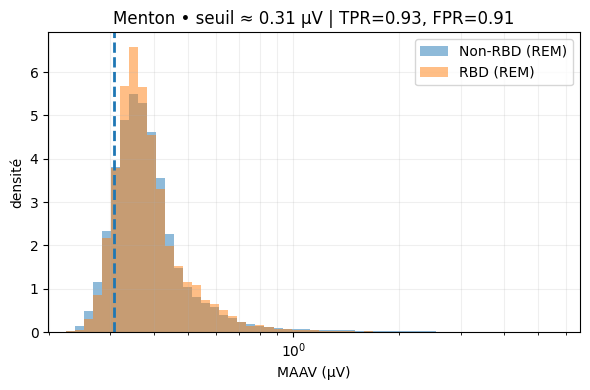

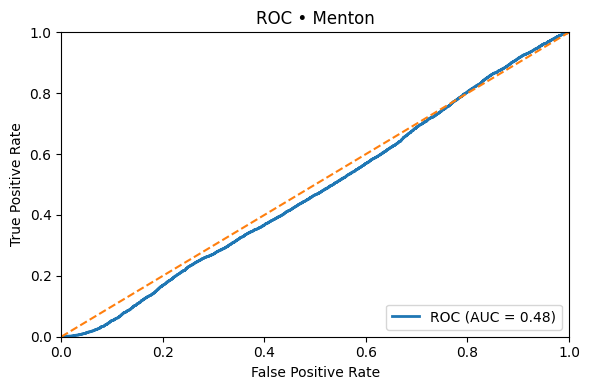

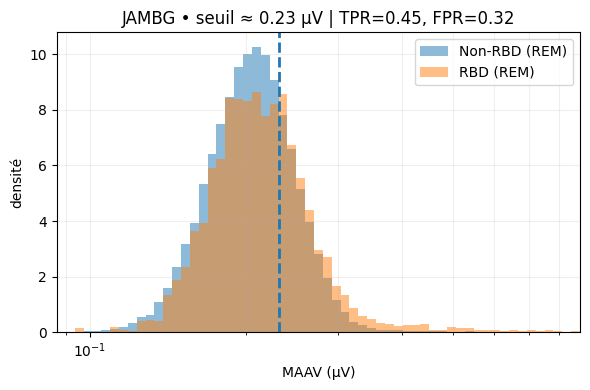

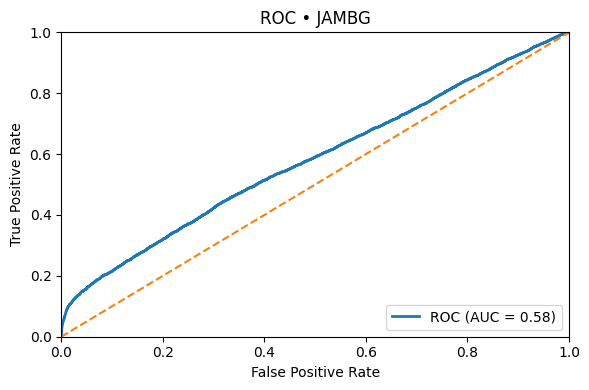

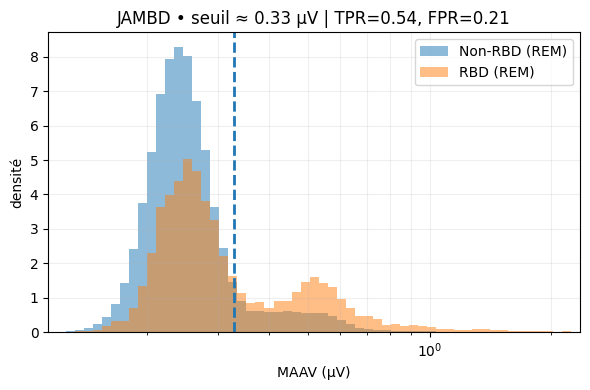

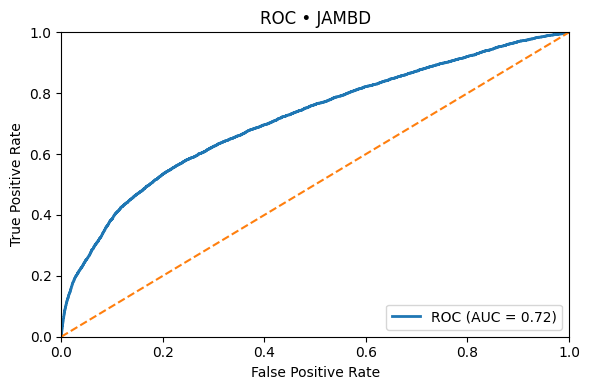

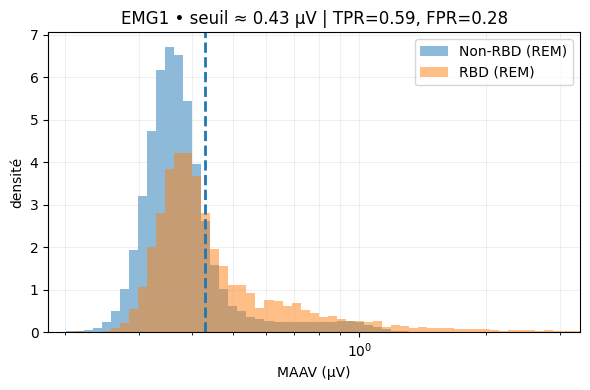

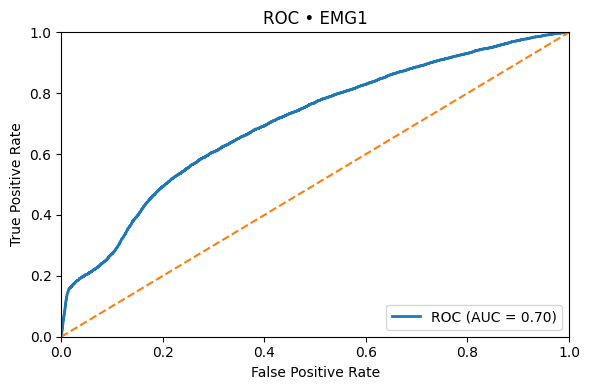

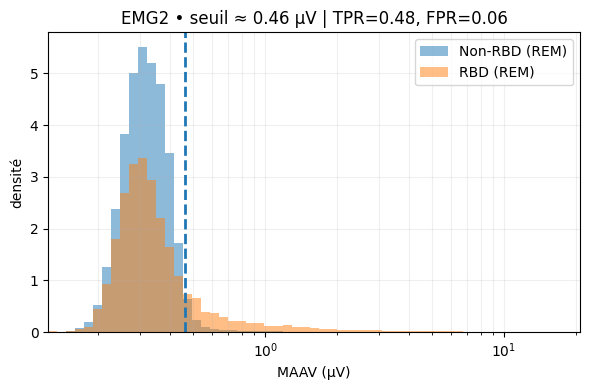

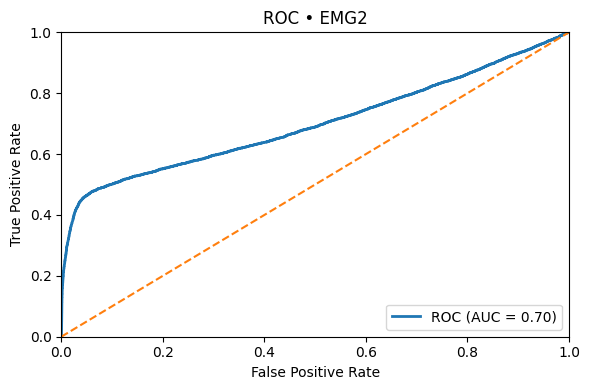


--- Seuils par canal (MAAV) ---


,channel,group,thr_volts,thr_uV,TPR,FPR,n_pos,n_neg
3,EMG1,arm,4.294477e-07,0.429448,0.585946,0.276068,5422,65386
4,EMG2,arm,4.627355e-07,0.462735,0.476392,0.059860,5422,65386
0,Menton,chin,3.080566e-07,0.308057,0.925489,0.910072,5422,65386
2,JAMBD,legs,3.271438e-07,0.327144,0.541313,0.205992,5422,65386
1,JAMBG,legs,2.315492e-07,0.231549,0.445223,0.320206,5422,65386



--- Seuils par groupe ---


,group,thr_volts,thr_uV,channels_in_group
0,arm,4.460916e-07,0.446092,"EMG1,EMG2"
1,chin,3.080566e-07,0.308057,Menton
2,legs,2.793465e-07,0.279346,"JAMBD,JAMBG"



Dictionnaire seuils (Volts) par canal:
{'Menton': 3.080565553756111e-07, 'JAMBG': 2.3154917668265676e-07, 'JAMBD': 3.2714375186351875e-07, 'EMG1': 4.294477476524086e-07, 'EMG2': 4.627354819225284e-07}

Dictionnaire seuils (Volts) par groupe:
{'arm': 4.460916147874685e-07, 'chin': 3.080565553756111e-07, 'legs': 2.7934646427308777e-07}


In [ ]:
# === À coller dans une cellule ===
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt
from IPython.display import display

# =============== Paramètres ===============
FIF_FILE = "/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/EF130/EF130_art_annotated.fif"

# MAAV
WIN_LEN_S = 0.1
OVERLAP   = 0.5

# Prétraitement EMG (pour l'estimation des seuils)
HP = 30.0; LP = 100.0
NOTCH_FREQ = 50.0; NOTCH_Q = 30.0
RESAMPLE_HZ = 500.0  # None pour garder la Fs d'origine

# Limites temporelles
EDGE_GUARD_S = 0.5   # marge pour ignorer ±0.5s autour des bords RBD (évite l'ambiguïté)
ONLY_REM = True      # n'utiliser que des fenêtres dont le centre est en REM

# Hypnogramme (adapter si besoin)
hypno_path = "/home/darryld/documents/EEG/raw/EF130/EF130_hypnoEXP.txt"
HYPNO_OFFSET_S = 0.0

# Groupes pour moyennage des seuils
def channel_group(ch_name: str) -> str:
    n = ch_name.lower()
    if "ment" in n or "chin" in n or "subment" in n:
        return "chin"
    if "jamb" in n:          # JAMBD / JAMBG
        return "legs"
    if "emg" in n:           # EMG1 / EMG2
        return "arm"
    return "other"

# --------- Utilitaires unités ---------
def to_uV(x_volts):      # Volts -> microvolts (pour affichage seulement)
    return np.asarray(x_volts) * 1e6

def from_uV(x_uV):       # microvolts -> Volts (si jamais tu lis un seuil saisi en µV)
    return np.asarray(x_uV) * 1e-6

# --------- Hypnogramme (REM) ---------
def read_hypnogram_intervals_rem(path: str):
    import os, pandas as pd, numpy as np
    if path is None or not os.path.isfile(path):
        return [], 30.0
    df = pd.read_csv(
        path, sep=r"\s+", engine="python", header=None, comment="#",
        names=["t_end_s", "hhmmss", "stage", "extra"],
        usecols=[0, 1, 2], dtype={0: float, 1: str, 2: str},
        encoding_errors="ignore"
    )
    df = df.dropna(subset=["t_end_s", "stage"]).copy()
    df["stage"] = df["stage"].astype(str).str.strip().str.upper()
    te = df["t_end_s"].to_numpy()
    diffs = np.diff(te) if len(te) > 1 else np.array([])
    epoch_len = float(pd.Series(np.round(diffs, 1)).mode().iloc[0]) if diffs.size else 30.0
    is_rem = df["stage"].isin(["R", "REM"])
    rem_intervals, run_start, prev_end = [], None, None
    for t_end, flag in zip(df["t_end_s"], is_rem):
        t_start = t_end - epoch_len
        if flag:
            if run_start is None:
                run_start = t_start
            prev_end = t_end
        else:
            if run_start is not None:
                rem_intervals.append((float(run_start), float(prev_end)))
                run_start, prev_end = None, None
    if run_start is not None and prev_end is not None:
        rem_intervals.append((float(run_start), float(prev_end)))
    return rem_intervals, epoch_len

# --------- MAAV ---------
def compute_maav(x, sfreq, win_len_s=WIN_LEN_S, overlap=OVERLAP):
    x = np.asarray(x).ravel()
    n = len(x)
    L = int(round(win_len_s * sfreq))
    H = int(round(L * (1 - overlap)))
    if L <= 0 or H <= 0:
        raise ValueError("Fenêtrage invalide.")
    starts = np.arange(0, max(n - L + 1, 0), H, dtype=int)
    mav, tcent, idxs = [], [], []
    for s0 in starts:
        s1 = s0 + L
        if s1 > n: break
        w = x[s0:s1]
        mav.append(np.mean(np.abs(w)))
        tcent.append((s0 + s1)/(2*sfreq))
        idxs.append((s0, s1))
    return np.asarray(mav), np.asarray(tcent), idxs

# --------- Prétraitement EMG ---------
def preprocess_emg_channel(raw: mne.io.BaseRaw, pick_idx: int,
                           hp=HP, lp=LP, notch_freq=NOTCH_FREQ, notch_q=NOTCH_Q,
                           resample_hz=RESAMPLE_HZ):
    raw1 = raw.copy()
    if not raw1.preload:
        raw1.load_data()
    ch_name = raw1.ch_names[pick_idx]
    if raw1.get_channel_types(picks=[pick_idx])[0] != 'emg':
        raw1.set_channel_types({ch_name: 'emg'})
    raw_m = raw1.copy().pick(picks=[pick_idx])
    raw_m.filter(l_freq=hp, h_freq=lp, method="iir", picks=[0], verbose=False)
    fs = raw_m.info['sfreq']
    b, a = iirnotch(w0=notch_freq/(fs/2), Q=notch_q)
    data = raw_m.get_data()
    data = filtfilt(b, a, data, axis=1)
    raw_m._data[:] = data
    if resample_hz is not None and abs(raw_m.info['sfreq'] - resample_hz) > 1e-6:
        raw_m.resample(resample_hz)
    return raw_m, ch_name

# --------- Helpers temps ---------
def in_any_interval(t: float, intervals, margin=0.0) -> bool:
    for a, b in intervals:
        if (a + margin) <= t <= (b - margin):
            return True
    return False

def restrict_to_intervals(tcent, intervals):
    mask = np.zeros_like(tcent, dtype=bool)
    for a, b in intervals:
        mask |= (tcent >= a) & (tcent <= b)
    return mask

# --------- ROC / Youden J ---------
def best_threshold_roc(scores, labels):
    scores = np.asarray(scores, float); labels = np.asarray(labels, int)
    try:
        from sklearn.metrics import roc_curve, auc
        fpr, tpr, thr = roc_curve(labels, scores)
        j = tpr - fpr
        idx = int(np.argmax(j))
        return float(thr[idx]), float(tpr[idx]), float(fpr[idx])
    except Exception:
        # Fallback si sklearn absent
        prc = np.percentile(scores, np.linspace(1, 99, 99))
        best, best_j, best_tpr, best_fpr = prc[0], -np.inf, 0.0, 1.0
        for th in prc:
            tp = np.sum((scores >= th) & (labels == 1))
            fn = np.sum((scores <  th) & (labels == 1))
            fp = np.sum((scores >= th) & (labels == 0))
            tn = np.sum((scores <  th) & (labels == 0))
            tpr = tp / (tp + fn) if (tp+fn)>0 else 0.0
            fpr = fp / (fp + tn) if (fp+tn)>0 else 0.0
            j = tpr - fpr
            if j > best_j:
                best, best_j, best_tpr, best_fpr = th, j, tpr, fpr
        return float(best), float(best_tpr), float(best_fpr)

def _roc_numpy(scores, y):
    scores = np.asarray(scores, float)
    y = np.asarray(y, int)
    order = np.argsort(-scores)
    scores, y = scores[order], y[order]
    P = (y == 1).sum()
    N = (y == 0).sum()
    uniq = np.r_[np.unique(scores), -np.inf][::-1]
    tpr = []
    fpr = []
    tp = fp = 0
    j = 0
    for thr in uniq:
        while j < len(scores) and scores[j] >= thr:
            if y[j] == 1: tp += 1
            else:         fp += 1
            j += 1
        tpr.append(tp / P if P > 0 else 0.0)
        fpr.append(fp / N if N > 0 else 0.0)
    return np.array(fpr), np.array(tpr), uniq

def _auc_trapz(x, y):
    order = np.argsort(x)
    return float(np.trapz(y[order], x[order]))

def plot_roc(scores, y, title="ROC"):
    fpr = tpr = thr = None
    auc_val = None
    try:
        from sklearn.metrics import roc_curve, auc
        fpr, tpr, thr = roc_curve(y, scores)
        auc_val = float(auc(fpr, tpr))
    except Exception:
        fpr, tpr, thr = _roc_numpy(scores, y)
        auc_val = _auc_trapz(fpr, tpr)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {auc_val:.2f})")
    ax.plot([0, 1], [0, 1], ls="--")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    return fpr, tpr, thr, auc_val

# ========= 0) Pré-requis depuis tes autres cellules =========
if 'windows_by_patient' not in globals():
    raise RuntimeError("Le dict 'windows_by_patient' est introuvable. Exécute d'abord la cellule Excel → windows_by_patient.")

# ========= 1) Charger FIF et récupérer REM + RBD =========
raw = mne.io.read_raw_fif(FIF_FILE, preload=True, verbose=False)

# Patient id d'après le chemin (simple heuristique)
from pathlib import Path
def extract_patient_id_from_path(fpath: str) -> str:
    p = Path(fpath).resolve()
    parts = list(p.parts)
    for i, seg in enumerate(parts):
        if seg.lower() == "gp2" and i + 1 < len(parts):
            return parts[i + 1]
    return p.parent.name
patient_id = extract_patient_id_from_path(FIF_FILE)

# Intervalles RBD manuels
wins = windows_by_patient.get(patient_id, [])
rbd_intervals = [(float(w['start']), float(w['end'])) for w in wins if ('start' in w and 'end' in w)]
if HYPNO_OFFSET_S:
    rbd_intervals = [(a + HYPNO_OFFSET_S, b + HYPNO_OFFSET_S) for (a, b) in rbd_intervals]

# Intervalles REM
rem_intervals, epoch_len = read_hypnogram_intervals_rem(hypno_path) if hypno_path else ([], 30.0)
if HYPNO_OFFSET_S:
    rem_intervals = [(a + HYPNO_OFFSET_S, b + HYPNO_OFFSET_S) for (a, b) in rem_intervals]

print(f"Patient {patient_id} | RBD labels: {len(rbd_intervals)} | REM blocs: {len(rem_intervals)}")

# ========= 2) Seuils par canal =========
emg_picks = mne.pick_types(raw.info, emg=True)
if len(emg_picks) == 0:
    raise RuntimeError("Aucun canal EMG détecté.")

results = []  # lignes: canal, thr_volts, thr_uV, TPR, FPR, n_pos, n_neg, group

for p in emg_picks:
    raw_emg, ch_name = preprocess_emg_channel(raw, p)
    x = raw_emg.get_data()[0]   # Volts (filtré)
    sf_loc = raw_emg.info["sfreq"]

    # MAAV et temps centre (absolu)
    maav, tcent_rel, idx_windows = compute_maav(x, sf_loc, WIN_LEN_S, OVERLAP)
    tcent_abs = tcent_rel + raw.first_time

    # Filtre REM si demandé
    if ONLY_REM and rem_intervals:
        mask_rem = restrict_to_intervals(tcent_abs, rem_intervals)
    else:
        mask_rem = np.ones_like(tcent_abs, dtype=bool)

    # Labels: 1 si centre en RBD (avec marge), sinon 0
    labels = np.array([1 if in_any_interval(t, rbd_intervals, margin=EDGE_GUARD_S) else 0 for t in tcent_abs])

    # Garde REM + non-NaN
    mask_keep = mask_rem & (~np.isnan(maav))
    maav_keep = maav[mask_keep]
    labels_keep = labels[mask_keep]

    n_pos = int(np.sum(labels_keep==1))
    n_neg = int(np.sum(labels_keep==0))

    if n_pos == 0 or n_neg == 0:
        print(f"- {ch_name}: classes insuffisantes (pos={n_pos}, neg={n_neg}) → seuil ignoré.")
        continue

    # Seuil en VOLTS (ROC / Youden)
    thr, tpr, fpr = best_threshold_roc(maav_keep, labels_keep)

    # Histo visuel (µV pour le tracé) - échelle log, avec ligne de seuil
    maav_uV = maav_keep * 1e6
    thr_uV  = thr * 1e6

    eps = max(1e-3, np.percentile(maav_uV, 0.1) / 10.0)  # µV
    hi = np.percentile(maav_uV, 99.5)
    lo = max(eps, np.min(maav_uV[maav_uV > 0]) if np.any(maav_uV > 0) else eps)
    bins_log = np.logspace(np.log10(lo), np.log10(hi), 60)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(maav_uV[labels_keep == 0], bins=bins_log, alpha=0.5, density=True, label="Non-RBD (REM)")
    ax.hist(maav_uV[labels_keep == 1], bins=bins_log, alpha=0.5, density=True, label="RBD (REM)")
    ax.axvline(thr_uV, linestyle="--", linewidth=2)
    ax.set_xscale("log"); ax.set_xlim(lo, hi)
    ax.set_xlabel("MAAV (µV)"); ax.set_ylabel("densité")
    ax.set_title(f"{ch_name} • seuil ≈ {thr_uV:.2f} µV | TPR={tpr:.2f}, FPR={fpr:.2f}")
    ax.grid(axis="both", which="both", alpha=0.2)
    ax.legend()
    plt.tight_layout(); plt.show()

    # Courbe ROC (en Volts)
    _ = plot_roc(maav_keep, labels_keep, title=f"ROC • {ch_name}")

    results.append({
        "channel": ch_name,
        "group": channel_group(ch_name),
        "thr_volts": float(thr),
        "thr_uV": float(to_uV(thr)),
        "TPR": float(tpr),
        "FPR": float(fpr),
        "n_pos": n_pos,
        "n_neg": n_neg,
    })

df_thr = pd.DataFrame(results).sort_values(["group","channel"])
print("\n--- Seuils par canal (MAAV) ---")
display(df_thr)

# ========= 3) Seuils par groupe (moyenne pondérée par n_pos + n_neg) =========
group_rows = []
for g, sub in df_thr.groupby("group"):
    w = (sub["n_pos"] + sub["n_neg"]).to_numpy()
    w = w / np.sum(w)
    thr_volts_g = float(np.sum(w * sub["thr_volts"].to_numpy()))
    group_rows.append({
        "group": g,
        "thr_volts": thr_volts_g,
        "thr_uV": float(to_uV(thr_volts_g)),
        "channels_in_group": ",".join(sub["channel"].tolist())
    })

df_group = pd.DataFrame(group_rows)
print("\n--- Seuils par groupe ---")
display(df_group)

thr_by_channel = {r["channel"]: r["thr_volts"] for r in results}
thr_by_group   = {r["group"]:   r["thr_volts"] for r in group_rows}

print("\nDictionnaire seuils (Volts) par canal:")
print(thr_by_channel)
print("\nDictionnaire seuils (Volts) par groupe:")
print(thr_by_group)


### On procède par patient et on fait une moyenne pour trouver nos seuils

In [ ]:
# === À coller dans une cellule ===
import os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt
from IPython.display import display

# ================= Paramètres =================
GP2_DIR = "/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/"
RAW_DIR = "/home/darryld/documents/EEG/raw/"

# MAAV
WIN_LEN_S = 0.1
OVERLAP   = 0.5

# Prétraitement EMG
HP = 30.0; LP = 100.0
NOTCH_FREQ = 50.0; NOTCH_Q = 30.0
RESAMPLE_HZ = 500.0   # None pour garder Fs d’origine

# Limites temporelles
EDGE_GUARD_S = 0.5     # marge autour des bords RBD
ONLY_REM = True        # on ne garde que les fenêtres centrées en REM

# =============================================================
# ===================== UTILITAIRES ===========================
# =============================================================

def to_uV(x): return np.asarray(x) * 1e6

def read_hypnogram_intervals_rem(path: str):
    """Lit les intervalles REM depuis un fichier d'hypnogramme .txt"""
    if path is None or not os.path.isfile(path):
        print(f"[WARN] Hypnogramme manquant : {path}")
        return [], 30.0
    df = pd.read_csv(path, sep=r"\s+", engine="python", header=None, comment="#",
                     names=["t_end_s","hhmmss","stage","extra"], usecols=[0,1,2],
                     dtype={0:float,1:str,2:str}, encoding_errors="ignore")
    df = df.dropna(subset=["t_end_s","stage"]).copy()
    df["stage"] = df["stage"].astype(str).str.strip().str.upper()
    te = df["t_end_s"].to_numpy()
    diffs = np.diff(te) if len(te)>1 else np.array([])
    epoch_len = float(pd.Series(np.round(diffs,1)).mode().iloc[0]) if diffs.size else 30.0
    is_rem = df["stage"].isin(["R","REM"])
    rem_intervals, run_start, prev_end = [], None, None
    for t_end, flag in zip(df["t_end_s"], is_rem):
        t_start = t_end - epoch_len
        if flag:
            if run_start is None: run_start = t_start
            prev_end = t_end
        else:
            if run_start is not None:
                rem_intervals.append((float(run_start), float(prev_end)))
                run_start, prev_end = None, None
    if run_start is not None and prev_end is not None:
        rem_intervals.append((float(run_start), float(prev_end)))
    return rem_intervals, epoch_len

def compute_maav(x, sfreq, win_len_s=WIN_LEN_S, overlap=OVERLAP):
    """Calcule la moyenne absolue par fenêtre (MAAV)"""
    x = np.asarray(x).ravel()
    n = len(x)
    L = int(round(win_len_s*sfreq))
    H = int(round(L*(1-overlap)))
    starts = np.arange(0, max(n-L+1,0), H, dtype=int)
    mav, tcent = [], []
    for s0 in starts:
        s1 = s0 + L
        if s1 > n: break
        mav.append(np.mean(np.abs(x[s0:s1])))
        tcent.append((s0+s1)/(2*sfreq))
    return np.asarray(mav), np.asarray(tcent), starts

def preprocess_emg_channel(raw: mne.io.BaseRaw, pick_idx: int,
                           hp=HP, lp=LP, notch_freq=NOTCH_FREQ, notch_q=NOTCH_Q,
                           resample_hz=RESAMPLE_HZ):
    """Filtrage bande-passante + notch + resampling"""
    raw1 = raw.copy().load_data()
    ch_name = raw1.ch_names[pick_idx]
    if raw1.get_channel_types(picks=[pick_idx])[0] != 'emg':
        raw1.set_channel_types({ch_name:'emg'})
    raw_m = raw1.copy().pick(picks=[pick_idx])
    raw_m.filter(l_freq=hp, h_freq=lp, method="iir", picks=[0], verbose=False)
    fs = raw_m.info['sfreq']
    b, a = iirnotch(w0=notch_freq/(fs/2), Q=notch_q)
    data = filtfilt(b, a, raw_m.get_data(), axis=1)
    raw_m._data[:] = data
    if resample_hz is not None and abs(raw_m.info['sfreq']-resample_hz) > 1e-6:
        raw_m.resample(resample_hz)
    return raw_m, ch_name

def in_any_interval(t: float, intervals, margin=0.0) -> bool:
    for a,b in intervals:
        if (a+margin) <= t <= (b-margin): return True
    return False

def restrict_to_intervals(tcent, intervals):
    mask = np.zeros_like(tcent, dtype=bool)
    for a,b in intervals:
        mask |= (tcent >= a) & (tcent <= b)
    return mask

def channel_group(ch_name: str) -> str:
    n = ch_name.lower()
    if any(k in n for k in ("menton","chin","subment","masseter")): return "chin"
    if "jamb" in n: return "legs"
    if "emg"  in n: return "arm"
    return "other"

def best_threshold_roc(scores, labels):
    """Calcule le meilleur seuil (Youden J)"""
    scores = np.asarray(scores, float); labels = np.asarray(labels, int)
    from sklearn.metrics import roc_curve
    fpr, tpr, thr = roc_curve(labels, scores)
    j = tpr - fpr
    mask = np.isfinite(thr)
    if mask.sum() == 0:
        med = float(np.median(scores))
        return med, 0.0, 0.0, (fpr,tpr)
    thr_f, tpr_f, fpr_f, j_f = thr[mask], tpr[mask], fpr[mask], j[mask]
    j_max = np.max(j_f)
    cand = np.where(j_f == j_max)[0]
    idx = int(cand[np.argmin(fpr_f[cand])])
    return float(thr_f[idx]), float(tpr_f[idx]), float(fpr_f[idx]), (fpr,tpr)

def avg_roc(curves, n_grid=300):
    """Moyenne pondérée des courbes ROC"""
    grid = np.linspace(0,1,n_grid)
    tprs=[]; ws=[]
    for fpr, tpr, w in curves:
        fpr = np.asarray(fpr); tpr = np.asarray(tpr)
        if fpr[0]>0 or tpr[0]>0:
            fpr = np.r_[0,fpr]; tpr = np.r_[0,tpr]
        if fpr[-1]<1 or tpr[-1]<1:
            fpr = np.r_[fpr,1]; tpr = np.r_[tpr,1]
        tprs.append(np.interp(grid,fpr,tpr)); ws.append(w)
    tprs = np.vstack(tprs); ws = np.asarray(ws,float)
    w /= ws.sum()
    tpr_mean = (ws[:,None]*tprs).sum(axis=0)
    auc_mean = float(np.trapz(tpr_mean, grid))
    return grid, tpr_mean, auc_mean

def find_patient_files(pid: str):
    fif = sorted(glob.glob(os.path.join(GP2_DIR, pid, "*annotated.fif")))
    hyp = sorted(glob.glob(os.path.join(RAW_DIR, pid, "*hypnoEXP.txt")))
    return (fif[0] if fif else None), (hyp[0] if hyp else None)

# =============================================================
# ==================== TRAITEMENT GLOBAL =======================
# =============================================================

if 'windows_by_patient' not in globals():
    raise RuntimeError(" `windows_by_patient` est introuvable : exécute d’abord la cellule de génération depuis l’Excel.")

patient_ids = sorted([pid for pid in windows_by_patient.keys() if os.path.isdir(os.path.join(GP2_DIR, pid))])
print(f"\n=== Début du traitement multi-patients ===")
print(f"Patients à traiter : {len(patient_ids)}\n{'='*50}")

per_group_scores, per_group_labels = {g:[] for g in ("chin","legs","arm")}, {g:[] for g in ("chin","legs","arm")}
per_group_roc_curv, per_group_thr = {g:[] for g in ("chin","legs","arm")}, {g:[] for g in ("chin","legs","arm")}
rows_patients = []

for pid in patient_ids:
    print(f"\n--- Patient {pid} ---")
    fif_path, hyp_path = find_patient_files(pid)
    if not fif_path:
        print(f" Fichier .fif introuvable → patient ignoré")
        continue

    rbd_intervals = [(float(w['start']), float(w['end'])) for w in windows_by_patient[pid]]
    if len(rbd_intervals)==0:
        print(f" Aucune fenêtre RBD dans Excel → patient ignoré")
        continue

    rem_intervals, _ = read_hypnogram_intervals_rem(hyp_path)
    raw = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)
    emg_picks = mne.pick_types(raw.info, emg=True)
    print(f"  Canaux EMG détectés : {len(emg_picks)}")

    pat_scores, pat_labels = {"chin":[], "legs":[], "arm":[]}, {"chin":[], "legs":[], "arm":[]}

    for p in emg_picks:
        raw_emg, ch_name = preprocess_emg_channel(raw, p)
        g = channel_group(ch_name)
        if g not in ("chin","legs","arm"):
            continue

        x = raw_emg.get_data()[0]
        sf = raw_emg.info["sfreq"]
        maav, tcent_rel, _ = compute_maav(x, sf, WIN_LEN_S, OVERLAP)
        tcent = tcent_rel + raw.first_time
        mask_rem = restrict_to_intervals(tcent, rem_intervals) if (ONLY_REM and rem_intervals) else np.ones_like(tcent,bool)
        labels = np.array([1 if in_any_interval(t, rbd_intervals, margin=EDGE_GUARD_S) else 0 for t in tcent])
        keep = mask_rem & (~np.isnan(maav))
        if keep.sum()==0: continue

        pat_scores[g].append(maav[keep])
        pat_labels[g].append(labels[keep])

    # Seuils par groupe
    for g in ("chin","legs","arm"):
        if len(pat_scores[g])==0: continue
        scores = np.concatenate(pat_scores[g])
        labels = np.concatenate(pat_labels[g])
        thr_v, tpr, fpr, (fpr_c, tpr_c) = best_threshold_roc(scores, labels)
        if not np.isfinite(thr_v):
            print(f" Seuil infini pour {g}, ignoré.")
            continue
        weight = float(len(scores))
        print(f"  {g:<6s} → seuil = {to_uV(thr_v):7.2f} µV | TPR={tpr:.2f}, FPR={fpr:.2f} | fenêtres={int(weight)}")

        per_group_scores[g].append(scores)
        per_group_labels[g].append(labels)
        per_group_roc_curv[g].append((fpr_c, tpr_c, weight))
        per_group_thr[g].append((thr_v, weight))
        rows_patients.append({
            "patient_id": pid, "group": g,
            "thr_volts": thr_v, "thr_uV": float(to_uV(thr_v)),
            "TPR_at_thr": tpr, "FPR_at_thr": fpr,
            "n_windows": int(weight),
            "n_rbd_windows": int((labels==1).sum())
        })

# =============================================================
# ===================== TABLEAUX MOYENS =======================
# =============================================================
df_pat = pd.DataFrame(rows_patients).sort_values(["group","patient_id"])
if df_pat.empty:
    raise RuntimeError(" Aucun résultat - vérifie les chemins ou le contenu des .fif / hypno / Excel.")

print("\n\n=== Seuils individuels par patient × groupe ===")
display(df_pat)

rows_glob=[]
for g in ("chin","legs","arm"):
    vals = [(t,w) for (t,w) in per_group_thr[g] if np.isfinite(t)]
    if not vals:
        print(f"[WARN] Aucun seuil exploitable pour le groupe {g}")
        continue
    thrs = np.array([t for (t,w) in vals], float)
    ws   = np.array([w for (t,w) in vals], float)
    thr_mean = float(np.sum(thrs*ws) / np.sum(ws))
    rows_glob.append({
        "group": g,
        "thr_volts": thr_mean,
        "thr_uV": float(to_uV(thr_mean)),
        "n_patients": len(ws),
        "total_windows": int(ws.sum())
    })
df_glob = pd.DataFrame(rows_glob).sort_values("group")

print("\n=== Seuils moyens pondérés (par groupe) ===")
display(df_glob)

# =============================================================
# ======================= FIGURES ==============================
# =============================================================
def plot_group_hist_and_roc(group_name):
    if len(per_group_scores[group_name])==0: return
    scores_uV = np.concatenate(per_group_scores[group_name]) * 1e6
    labels    = np.concatenate(per_group_labels[group_name])

    eps = max(1e-3, np.percentile(scores_uV, 0.1)/10.0)
    lo  = max(eps, np.min(scores_uV[scores_uV>0]) if np.any(scores_uV>0) else eps)
    hi  = np.percentile(scores_uV, 99.5)
    bins = np.logspace(np.log10(lo), np.log10(hi), 70)
    thr_uV = float(df_glob.loc[df_glob["group"].eq(group_name), "thr_uV"].iloc[0])

    print(f"\n- Génération figures pour groupe {group_name} (seuil moyen = {thr_uV:.2f} µV)")

    # Histogrammes
    fig, ax = plt.subplots(figsize=(7,4.2))
    ax.hist(scores_uV[labels==0], bins=bins, alpha=0.5, density=True, label="Non-RBD (REM)")
    ax.hist(scores_uV[labels==1], bins=bins, alpha=0.5, density=True, label="RBD (REM)")
    ax.axvline(thr_uV, ls="--", lw=2, color="k", label=f"Seuil moyen ≈ {thr_uV:.2f} µV")
    ax.set_xscale("log"); ax.set_xlim(lo, hi)
    ax.set_xlabel("MAAV (µV)"); ax.set_ylabel("densité")
    ax.set_title(f"Histogrammes MAAV • groupe {group_name}")
    ax.grid(which="both", alpha=0.2); ax.legend()
    plt.tight_layout(); plt.show()

    # ROC moyenne
    fpr_grid, tpr_mean, auc_mean = avg_roc(per_group_roc_curv[group_name])
    fig, ax = plt.subplots(figsize=(7,4.2))
    ax.plot(fpr_grid, tpr_mean, lw=2, label=f"ROC moyenne (AUC = {auc_mean:.2f})")
    ax.plot([0,1],[0,1],"--", alpha=0.5)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC moyenne • groupe {group_name}")
    ax.legend(loc="lower right"); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

for g in ("chin","legs","arm"):
    if g in df_glob["group"].values:
        plot_group_hist_and_roc(g)

print("\n- Traitement terminé pour tous les patients.")



=== Début du traitement multi-patients ===
Patients à traiter : 53

--- Patient AE129 ---


/tmp/ipykernel_1078324/1086176665.py:179: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/AE129/AE129_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)


  Canaux EMG détectés : 5
  chin   → seuil =    1.51 µV | TPR=0.37, FPR=0.30 | fenêtres=234647
  legs   → seuil =    0.33 µV | TPR=0.70, FPR=0.38 | fenêtres=469294
  arm    → seuil =    3.90 µV | TPR=0.85, FPR=0.62 | fenêtres=469294

--- Patient BA152 ---


/tmp/ipykernel_1078324/1086176665.py:179: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/BA152/BA152_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)


  Canaux EMG détectés : 5
  chin   → seuil =    2.57 µV | TPR=0.60, FPR=0.26 | fenêtres=69607
  legs   → seuil =    0.53 µV | TPR=0.58, FPR=0.40 | fenêtres=139214
  arm    → seuil =    1.10 µV | TPR=0.36, FPR=0.18 | fenêtres=139214

--- Patient BA171 ---


...

  Canaux EMG détectés : 5
  chin   → seuil =    0.37 µV | TPR=0.72, FPR=0.66 | fenêtres=36008
  legs   → seuil =    0.24 µV | TPR=0.29, FPR=0.25 | fenêtres=72016
  arm    → seuil =    0.31 µV | TPR=0.64, FPR=0.27 | fenêtres=72016

--- Patient BB114 ---


/tmp/ipykernel_1078324/1086176665.py:179: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/BB114/BB114_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)


  Canaux EMG détectés : 5
  chin   → seuil =    4.37 µV | TPR=0.67, FPR=0.27 | fenêtres=110419
  legs   → seuil =    0.64 µV | TPR=0.67, FPR=0.46 | fenêtres=220838
  arm    → seuil =    3.70 µV | TPR=0.63, FPR=0.36 | fenêtres=220838

--- Patient BF181 ---


/tmp/ipykernel_1078324/1086176665.py:179: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/BF181/BF181_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=True, verbose=False)


  Canaux EMG détectés : 5


### Étudions la répartition des seuils trouvés : 

=== Effectifs par groupe ===
group
chin    48
arm     38
legs    48
dtype: int64

=== Médianes par groupe ===
       thr_uV_median  TPR_median  FPR_median
group                                       
chin        1.576240    0.621627    0.326201
arm         1.614674    0.469574    0.245012
legs        0.500932    0.470137    0.233614


/tmp/ipykernel_2397748/3054603100.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("group").size())
/tmp/ipykernel_2397748/3054603100.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("group")[["thr_uV","TPR_at_thr","FPR_at_thr"]].median().rename(
/tmp/ipykernel_2397748/3054603100.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(thr_arrays, labels=labels, patch_artist=True, showfliers=True)


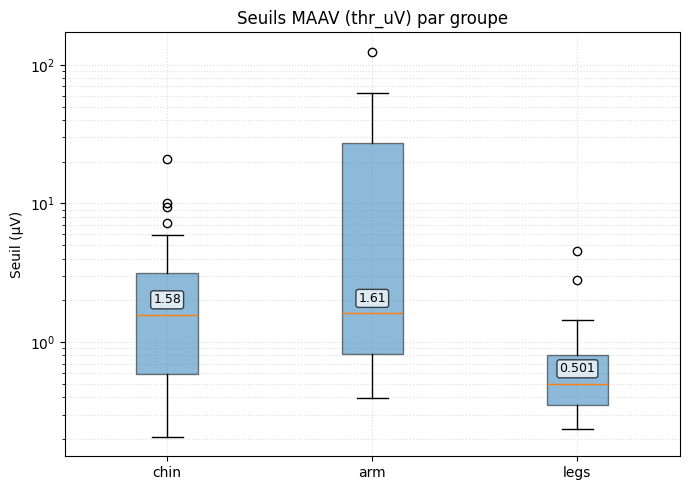

/tmp/ipykernel_2397748/3054603100.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(tpr_arrays, labels=labels, patch_artist=True, showfliers=True)


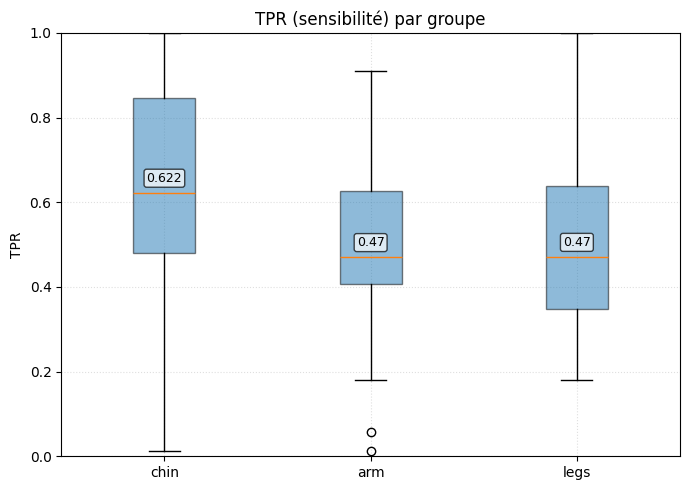

/tmp/ipykernel_2397748/3054603100.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax3.boxplot(fpr_arrays, labels=labels, patch_artist=True, showfliers=True)


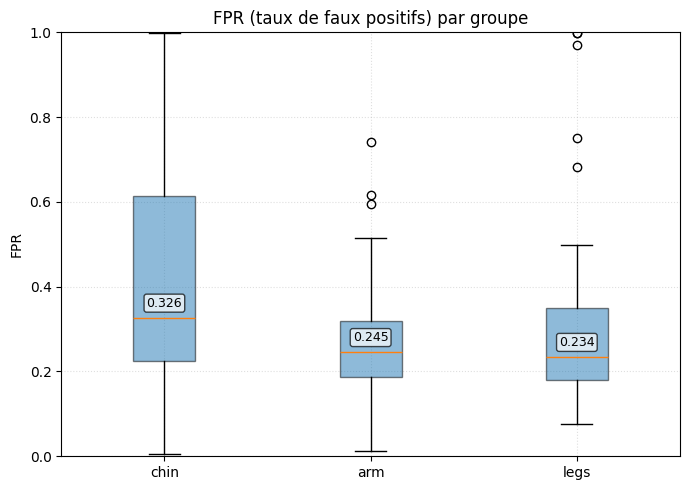


Figures sauvegardées :
 - /home/darryld/Cerco_studies/notebooks/box_thr_uV.png
 - /home/darryld/Cerco_studies/notebooks/box_tpr.png
 - /home/darryld/Cerco_studies/notebooks/box_fpr.png


In [10]:
# --- Boxplots MAAV par groupe (matplotlib pur) ---

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "/home/darryld/Cerco_studies/data/out_thresholds_maav/thresholds_by_patient_maav.csv"  # adapte si besoin

# Chargement
df = pd.read_csv(CSV_PATH)

# Garde-fous et nettoyage
df = df.copy()
df["group"] = df["group"].astype(str).str.lower().str.strip()
order = ["chin", "arm", "legs"]
df = df[df["group"].isin(order)].copy()
df["group"] = pd.Categorical(df["group"], categories=order, ordered=True)

# Filtrages NaN / inf
for col in ["thr_uV", "TPR_at_thr", "FPR_at_thr"]:
    if col in df:
        df = df[np.isfinite(df[col])]

# Stats rapides
print("=== Effectifs par groupe ===")
print(df.groupby("group").size())
print("\n=== Médianes par groupe ===")
print(df.groupby("group")[["thr_uV","TPR_at_thr","FPR_at_thr"]].median().rename(
    columns={"thr_uV":"thr_uV_median","TPR_at_thr":"TPR_median","FPR_at_thr":"FPR_median"}
))

# Préparation des données par groupe
def _series_by_group(col):
    arrays = [df.loc[df["group"]==g, col].to_numpy() for g in order]
    labels = [g for g in order]
    return arrays, labels

# --- PATCH: helper pour annoter médiane sur CHAQUE box ---
def annotate_medians(ax, arrays, fmt="med={:.3g}", dy=0.0):
    """
    Place un texte 'med=...' à la hauteur exacte de la médiane de chaque box.
    - ax : axes matplotlib
    - arrays : liste/tuple d'arrays (une entrée par box) OU un seul array
    - fmt : format du texte
    - dy : léger décalage vertical en unités 'données' (0 par défaut)
    """
    import numpy as np
    if not isinstance(arrays, (list, tuple)):
        arrays = [arrays]
    for i, data in enumerate(arrays, start=1):
        data = np.asarray(data)
        data = data[np.isfinite(data)]
        if data.size == 0:
            continue
        med = float(np.percentile(data, 50))
        ax.annotate(fmt.format(med),
                    xy=(i, med), xytext=(0, 6), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))




# 1) Boxplot des seuils (thr_uV) en échelle log
thr_arrays, labels = _series_by_group("thr_uV")
fig1, ax1 = plt.subplots(figsize=(7,5))
bp1 = ax1.boxplot(thr_arrays, labels=labels, patch_artist=True, showfliers=True)
# petite coloration
for patch in bp1['boxes']:
    patch.set_alpha(0.5)
ax1.set_yscale("log")
ax1.set_ylabel("Seuil (µV)")
ax1.set_title("Seuils MAAV (thr_uV) par groupe")
ax1.grid(True, which="both", ls=":", alpha=0.4)
annotate_medians(ax1, thr_arrays, fmt="{:.3g}") 
fig1.tight_layout()
fig1.savefig("box_thr_uV.png", dpi=150)
plt.show()

# 2) Boxplot TPR
tpr_arrays, labels = _series_by_group("TPR_at_thr")
fig2, ax2 = plt.subplots(figsize=(7,5))
bp2 = ax2.boxplot(tpr_arrays, labels=labels, patch_artist=True, showfliers=True)
for patch in bp2['boxes']:
    patch.set_alpha(0.5)
ax2.set_ylim(0, 1)
ax2.set_ylabel("TPR")
ax2.set_title("TPR (sensibilité) par groupe")
ax2.grid(True, ls=":", alpha=0.4)
annotate_medians(ax2, tpr_arrays, fmt="{:.3g}") 
fig2.tight_layout()
fig2.savefig("box_tpr.png", dpi=150)
plt.show()

# 3) Boxplot FPR
fpr_arrays, labels = _series_by_group("FPR_at_thr")
fig3, ax3 = plt.subplots(figsize=(7,5))
bp3 = ax3.boxplot(fpr_arrays, labels=labels, patch_artist=True, showfliers=True)
for patch in bp3['boxes']:
    patch.set_alpha(0.5)
ax3.set_ylim(0, 1)
ax3.set_ylabel("FPR")
ax3.set_title("FPR (taux de faux positifs) par groupe")
ax3.grid(True, ls=":", alpha=0.4)
annotate_medians(ax3, fpr_arrays, fmt="{:.3g}") 
fig3.tight_layout()
fig3.savefig("box_fpr.png", dpi=150)
plt.show()

print("\nFigures sauvegardées :",
      os.path.abspath("box_thr_uV.png"),
      os.path.abspath("box_tpr.png"),
      os.path.abspath("box_fpr.png"),
      sep="\n - ")


=== Effectifs par groupe ===
group
chin    48
arm     38
legs    48
dtype: int64

=== Médianes par groupe ===
       thr_uV_median  TPR_median  FPR_median
group                                       
chin        1.025669    0.539327    0.295538
arm         1.201597    0.441759    0.221448
legs        0.509816    0.331904    0.179021


/tmp/ipykernel_2397748/1607976703.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("group").size())
/tmp/ipykernel_2397748/1607976703.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("group")[["thr_uV","TPR_at_thr","FPR_at_thr"]].median().rename(
/tmp/ipykernel_2397748/1607976703.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(thr_arrays, labels=labels, patch_artist=True, showfliers=True)


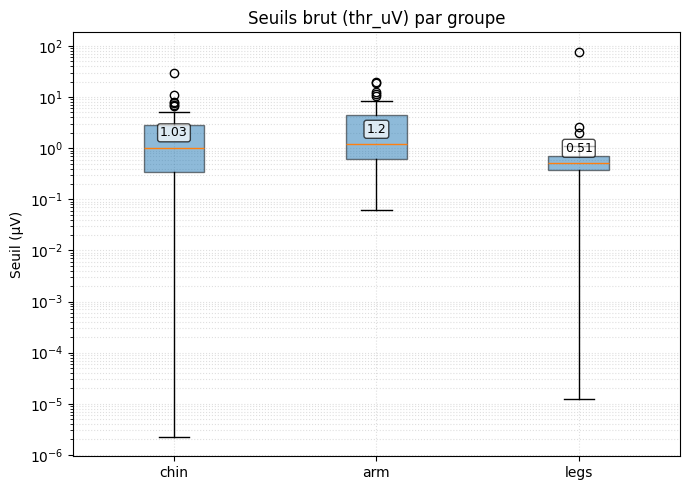

/tmp/ipykernel_2397748/1607976703.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(tpr_arrays, labels=labels, patch_artist=True, showfliers=True)


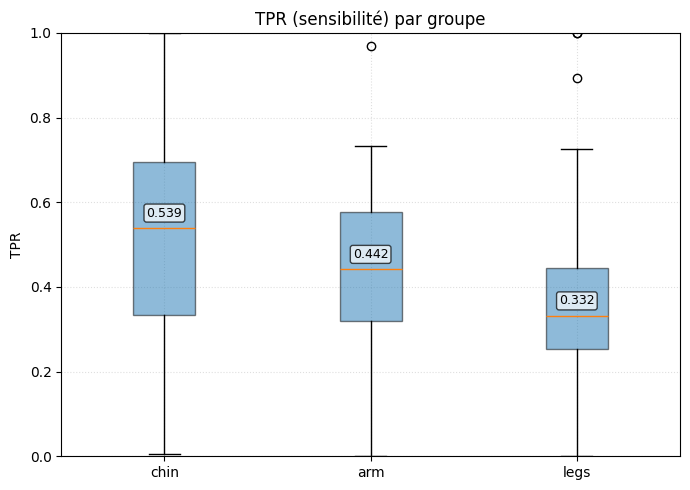

/tmp/ipykernel_2397748/1607976703.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax3.boxplot(fpr_arrays, labels=labels, patch_artist=True, showfliers=True)


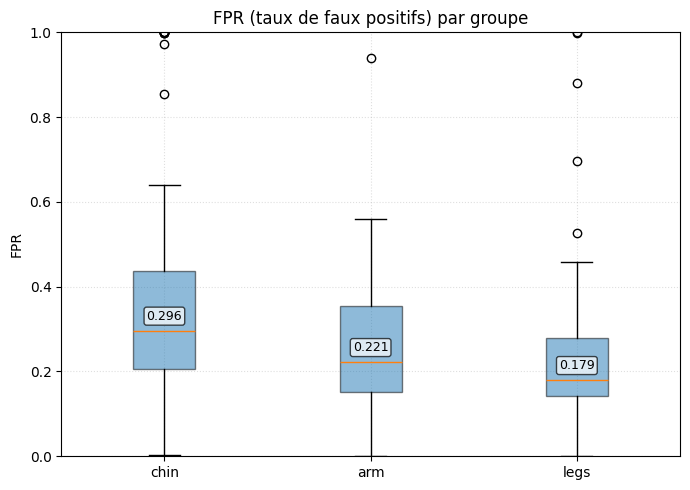


Figures sauvegardées :
 - /home/darryld/Cerco_studies/notebooks/box_thr_uV.png
 - /home/darryld/Cerco_studies/notebooks/box_tpr.png
 - /home/darryld/Cerco_studies/notebooks/box_fpr.png


In [11]:
# --- Boxplots MAAV par groupe (matplotlib pur) ---

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "/home/darryld/Cerco_studies/data/out_thresholds_raw/thresholds_by_patient_raw.csv" 

# Chargement
df = pd.read_csv(CSV_PATH)

# Garde-fous et nettoyage
df = df.copy()
df["group"] = df["group"].astype(str).str.lower().str.strip()
order = ["chin", "arm", "legs"]
df = df[df["group"].isin(order)].copy()
df["group"] = pd.Categorical(df["group"], categories=order, ordered=True)

# Filtrages NaN / inf
for col in ["thr_uV", "TPR_at_thr", "FPR_at_thr"]:
    if col in df:
        df = df[np.isfinite(df[col])]

# Stats rapides
print("=== Effectifs par groupe ===")
print(df.groupby("group").size())
print("\n=== Médianes par groupe ===")
print(df.groupby("group")[["thr_uV","TPR_at_thr","FPR_at_thr"]].median().rename(
    columns={"thr_uV":"thr_uV_median","TPR_at_thr":"TPR_median","FPR_at_thr":"FPR_median"}
))

# Préparation des données par groupe
def _series_by_group(col):
    arrays = [df.loc[df["group"]==g, col].to_numpy() for g in order]
    labels = [g for g in order]
    return arrays, labels

# --- PATCH: helper pour annoter médiane sur CHAQUE box ---
def annotate_medians(ax, arrays, fmt="med={:.3g}", dy=0.0):
    """
    Place un texte 'med=...' à la hauteur exacte de la médiane de chaque box.
    - ax : axes matplotlib
    - arrays : liste/tuple d'arrays (une entrée par box) OU un seul array
    - fmt : format du texte
    - dy : léger décalage vertical en unités 'données' (0 par défaut)
    """
    import numpy as np
    if not isinstance(arrays, (list, tuple)):
        arrays = [arrays]
    for i, data in enumerate(arrays, start=1):
        data = np.asarray(data)
        data = data[np.isfinite(data)]
        if data.size == 0:
            continue
        med = float(np.percentile(data, 50))
        ax.annotate(fmt.format(med),
                    xy=(i, med), xytext=(0, 6), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))



# 1) Boxplot des seuils (thr_uV) en échelle log
thr_arrays, labels = _series_by_group("thr_uV")
fig1, ax1 = plt.subplots(figsize=(7,5))
bp1 = ax1.boxplot(thr_arrays, labels=labels, patch_artist=True, showfliers=True)
# petite coloration
for patch in bp1['boxes']:
    patch.set_alpha(0.5)
ax1.set_yscale("log")
ax1.set_ylabel("Seuil (µV)")
ax1.set_title("Seuils brut (thr_uV) par groupe")
ax1.grid(True, which="both", ls=":", alpha=0.4)
annotate_medians(ax1, thr_arrays, fmt="{:.3g}") 
fig1.tight_layout()
fig1.savefig("box_thr_uV.png", dpi=150)
plt.show()

# 2) Boxplot TPR
tpr_arrays, labels = _series_by_group("TPR_at_thr")
fig2, ax2 = plt.subplots(figsize=(7,5))
bp2 = ax2.boxplot(tpr_arrays, labels=labels, patch_artist=True, showfliers=True)
for patch in bp2['boxes']:
    patch.set_alpha(0.5)
ax2.set_ylim(0, 1)
ax2.set_ylabel("TPR")
ax2.set_title("TPR (sensibilité) par groupe")
ax2.grid(True, ls=":", alpha=0.4)
annotate_medians(ax2, tpr_arrays, fmt="{:.3g}")
fig2.tight_layout()
fig2.savefig("box_tpr.png", dpi=150)
plt.show()

# 3) Boxplot FPR
fpr_arrays, labels = _series_by_group("FPR_at_thr")
fig3, ax3 = plt.subplots(figsize=(7,5))
bp3 = ax3.boxplot(fpr_arrays, labels=labels, patch_artist=True, showfliers=True)
for patch in bp3['boxes']:
    patch.set_alpha(0.5)
ax3.set_ylim(0, 1)
ax3.set_ylabel("FPR")
ax3.set_title("FPR (taux de faux positifs) par groupe")
ax3.grid(True, ls=":", alpha=0.4)
annotate_medians(ax3, fpr_arrays, fmt="{:.3g}")
fig3.tight_layout()
fig3.savefig("box_fpr.png", dpi=150)
plt.show()

print("\nFigures sauvegardées :",
      os.path.abspath("box_thr_uV.png"),
      os.path.abspath("box_tpr.png"),
      os.path.abspath("box_fpr.png"),
      sep="\n - ")


## RBD identification (C. Peyron)

/tmp/ipykernel_1864266/476886462.py:128: RuntimeWarning: This filename (/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/CJP53/CJP53_art_annotated.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)


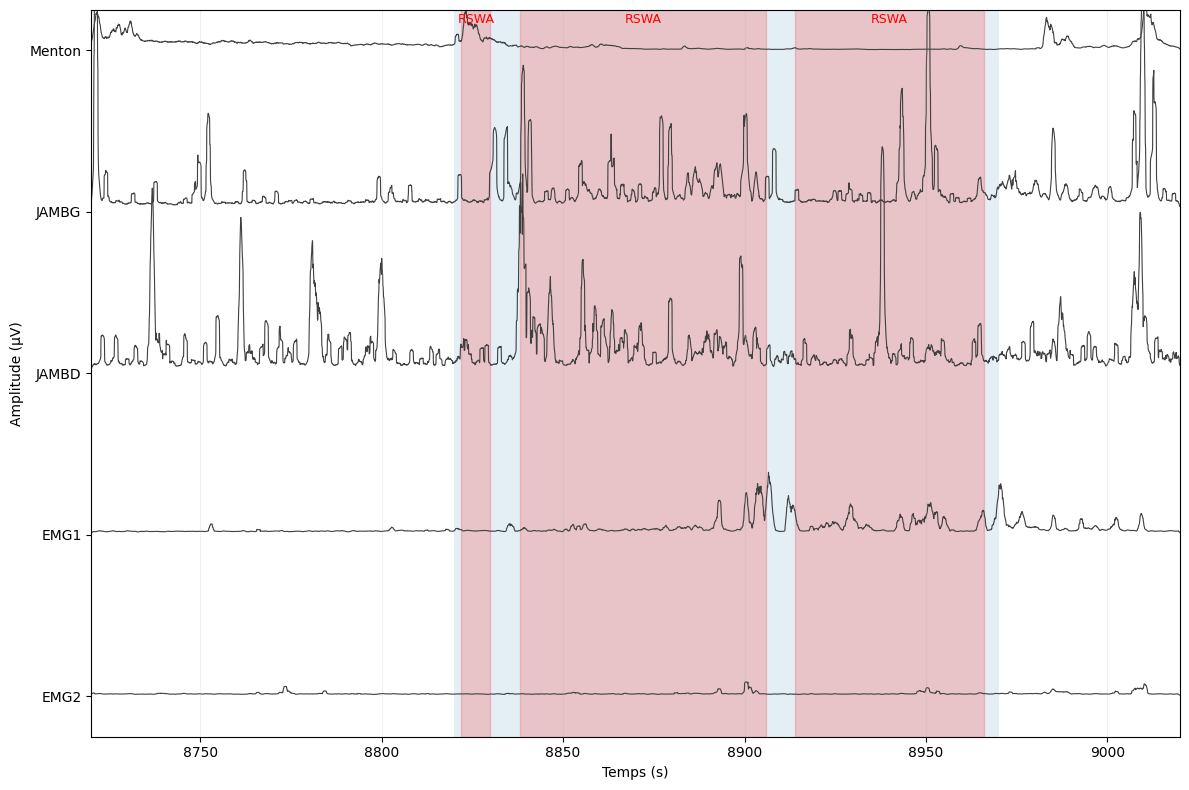

In [13]:
# === À coller dans une cellule ===
import os
from pathlib import Path
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# ========= Paramètres =========
patient_id = "CJP53"
hypno_path = f"/home/darryld/documents/EEG/raw/{patient_id}/{patient_id}_hypnoEXP.txt"
fif_file   = f"/home/darryld/documents/EEG/preprocessed/bipolaire/1_noArtefacts/gp2/{patient_id}/{patient_id}_art_annotated.fif"
EVENTS_CSV = "/home/darryld/Cerco_studies/data/rbd_emg_events_and_summary_4s.csv"  # REM_SUMMARY avec tonic_ratio

SHOW_REM_SHADE = True
HYPNO_OFFSET_S = 0.0         # décalage des REM si besoin
RSWA_OFFSET_S  = 0.0         # décalage éventuel des intervalles RSWA

# Affichage "page"
page_sec   = 300.0
page_start = 8720.0
max_channels = 20
DECIM_TARGET_PTS = 6000
PICK_EEG, PICK_EOG, PICK_EMG = False, False, True

# GAIN VISUEL des canaux EMG (insensible à la casse, match par inclusion)
EMG_GAINS = {"EMG1": 2.0, "EMG2": 2.0, "JAMBG": 10.0, "JAMBD": 10.0}

# ========= Utilitaires =========
def extract_patient_id_from_path(fpath: str) -> str:
    p = Path(fpath).resolve()
    parts = list(p.parts)
    for i, seg in enumerate(parts):
        if seg.lower() == "gp2" and i + 1 < len(parts):
            return parts[i + 1]
    return p.parent.name  # fallback

def build_union_mask(times: np.ndarray, intervals):
    mask = np.zeros_like(times, dtype=bool)
    for (a, b) in intervals:
        if b > a:
            mask |= (times >= a) & (times < b)
    return mask

def read_hypnogram_intervals_rem(path):
    """Lit un *_hypnoEXP.txt ; renvoie [(start,end)], epoch_len."""
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Hypnogramme introuvable: {path}")
    df = pd.read_csv(path, sep=r"\s+", engine="python", header=None, comment="#",
                     names=["t_end_s","hhmmss","stage"], usecols=[0,1,2],
                     dtype={0:float,1:str,2:str}, encoding_errors="ignore")
    df = df.dropna(subset=["t_end_s","stage"]).copy()
    df["t_end_s"] = pd.to_numeric(df["t_end_s"], errors="coerce")
    df = df.dropna(subset=["t_end_s"]).sort_values("t_end_s")
    df["stage"] = df["stage"].astype(str).str.strip().str.upper()
    te = df["t_end_s"].to_numpy()
    diffs = np.diff(te) if te.size>1 else np.array([])
    epoch_len = float(pd.Series(np.round(diffs,1)).mode().iloc[0]) if diffs.size else 30.0
    is_rem = df["stage"].isin(["R","REM"])
    rem_intervals, run_start, prev_end = [], None, None
    for t_end, flag in zip(df["t_end_s"], is_rem):
        t_start = t_end - epoch_len
        if flag:
            if run_start is None: run_start = t_start
            prev_end = t_end
        else:
            if run_start is not None:
                rem_intervals.append((float(run_start), float(prev_end)))
                run_start, prev_end = None, None
    if run_start is not None and prev_end is not None:
        rem_intervals.append((float(run_start), float(prev_end)))
    return rem_intervals, epoch_len

def load_rswa_intervals(csv_path, patient_id, merge_gap_s=0.01):
    """
    Retourne des intervalles (start, end) RSWA pour le patient depuis un export 4 s.
    - Lit les lignes type=="REM_EPOCH_4S" avec rswa==True
    - Fusionne les époques contiguës (gap <= merge_gap_s)
    """
    if not os.path.isfile(csv_path):
        print(f"[WARN] EVENTS_CSV introuvable: {csv_path}")
        return []

    df = pd.read_csv(csv_path)
    df = df[df.get("patient_id", "") == patient_id].copy()
    if df.empty:
        return []

    out = []
    need = {"type", "epoch_start_sec", "epoch_end_sec", "rswa"}
    if need.issubset(df.columns):
        sub = df[(df["type"] == "REM_EPOCH_4S") & (df["rswa"].astype(bool))]
        sub = sub[["epoch_start_sec", "epoch_end_sec"]].astype(float).sort_values("epoch_start_sec")
        merged = []
        for s, e in zip(sub["epoch_start_sec"], sub["epoch_end_sec"]):
            if not merged or s - merged[-1][1] > merge_gap_s:
                merged.append([s, e])
            else:
                merged[-1][1] = max(merged[-1][1], e)
        out = [(s, e) for s, e in merged if e > s]
    else:
        print("[WARN] Colonnes attendues absentes pour REM_EPOCH_4S.")
        out = []

    return out


def moving_average(x: np.ndarray, win_samps: int) -> np.ndarray:
    if win_samps <= 1: return x.copy()
    k = np.ones(win_samps, dtype=float)/win_samps
    pad = win_samps//2
    x_pad = np.pad(x, (pad,pad), mode="edge")
    y = np.convolve(x_pad, k, mode="valid")
    return y[:len(x)]

# ========= 2) Intervalles REM / RSWA =========
rem_intervals, epoch_len = [], 30.0
if SHOW_REM_SHADE and hypno_path and os.path.isfile(hypno_path):
    rem_intervals, epoch_len = read_hypnogram_intervals_rem(hypno_path)
    if HYPNO_OFFSET_S:
        rem_intervals = [(a+HYPNO_OFFSET_S, b+HYPNO_OFFSET_S) for (a,b) in rem_intervals]

rswa_intervals = load_rswa_intervals(EVENTS_CSV, patient_id)
if RSWA_OFFSET_S:
    rswa_intervals = [(a+RSWA_OFFSET_S, b+RSWA_OFFSET_S) for (a,b) in rswa_intervals]

# ========= 3) Charger le FIF =========
raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
sfreq = raw.info["sfreq"]

# ========= 4) Choix canaux & page =========
picks = mne.pick_types(raw.info, meg=False, eeg=PICK_EEG, eog=PICK_EOG, emg=PICK_EMG, stim=False, misc=False)
picks = picks[:max_channels]
if len(picks) == 0:
    raise RuntimeError("Aucun canal sélectionné (vérifie PICK_EEG/EOG/EMG).")

i0 = int((page_start - raw.first_time) * sfreq)
i1 = int(((page_start + page_sec) - raw.first_time) * sfreq)
i0 = max(i0, 0); i1 = min(i1, raw.n_times)

data, times = raw.get_data(picks=picks, start=i0, stop=i1, return_times=True)
# unité µV (filtrage linéaire, donc OK d'être en µV)
data = data * 1e6
data = data - np.median(data, axis=1, keepdims=True)

# -------- Prétraitement EOG AVANT décimation (0.3–10 Hz) --------
eog_all = mne.pick_types(raw.info, meg=False, eeg=False, eog=True, emg=False, stim=False, misc=False)
eog_in_picks = [np.where(picks == ep)[0][0] for ep in eog_all if ep in picks]
if eog_in_picks:
    data[eog_in_picks, :] = mne.filter.filter_data(
        data=data[eog_in_picks, :], sfreq=sfreq, l_freq=0.3, h_freq=10.0, verbose=False
    )

# -------- Prétraitement EMG AVANT décimation (HP 50 Hz + rectif + lissage 1 s) --------
emg_all = mne.pick_types(raw.info, meg=False, eeg=False, eog=False, emg=True, stim=False, misc=False)
emg_in_picks = [np.where(picks == ep)[0][0] for ep in emg_all if ep in picks]
if emg_in_picks:
    # HP 50 Hz
    data_hp = mne.filter.filter_data(data=data[emg_in_picks, :], sfreq=sfreq, l_freq=50.0, h_freq=None, verbose=False)
    # Rectification
    data_rect = np.abs(data_hp)
    # Lissage 1 s (en échantillons @ sfreq)
    win = max(1, int(round(sfreq * 1.0)))
    for k, idx in enumerate(emg_in_picks):
        data[idx, :] = moving_average(data_rect[k, :], win)

# -------- Décimation pour affichage --------
decim = max(1, data.shape[1] // DECIM_TARGET_PTS)
if decim > 1:
    data = data[:, ::decim]
    times = times[::decim]

# Appliquer les gains visuels sur EMG (après décimation)
if EMG_GAINS:
    ch_names = [raw.ch_names[p] for p in picks]
    scale = np.ones(len(picks), dtype=float)
    for i, nm in enumerate(ch_names):
        low = nm.lower()
        for key, gain in EMG_GAINS.items():
            if key.lower() in low:
                scale[i] = float(gain); break
    data = data * scale[:, None]

# Intersections avec la page
page_a, page_b = page_start, page_start + page_sec
def clip_to_page(intervals):
    out = []
    for a, b in intervals:
        aa, bb = max(a, page_a), min(b, page_b)
        if bb > aa:
            out.append((aa, bb))
    return out

rem_in_page  = clip_to_page(rem_intervals)
rswa_in_page = clip_to_page(rswa_intervals)

# ========= 5) Tracé (gris + REM bleu + RSWA rouge) =========
spacing = np.nanpercentile(np.abs(data), 95) if data.size else 1.0
spacing = spacing if spacing > 0 else 1.0
offsets = np.arange(len(picks))[::-1] * (spacing * 4.0)
data_stack = data + offsets[:, None]

fig, ax = plt.subplots(figsize=(12, 8))

# Ombre REM en fond (bleu clair)
for (aa, bb) in rem_in_page:
    ax.axvspan(aa, bb, alpha=0.12, zorder=0.3)

# Ombre RSWA (tonic_ratio > 1) en rouge par-dessus
for (aa, bb) in rswa_in_page:
    ax.axvspan(aa, bb, color='red', alpha=0.18, zorder=0.4)
    try:
        ax.text((aa+bb)/2, offsets[0] + 0.6*spacing, "RSWA", ha='center', va='bottom', fontsize=9, color='red')
    except Exception:
        pass

# Signaux en gris (EMG = enveloppe HP50+rectif+lissage)
for ch_idx in range(len(picks)):
    ax.plot(times, data_stack[ch_idx], lw=0.8, color='0.25', zorder=1.0)

ax.set_xlim(page_a, page_b)
ax.set_ylim(offsets[-1] - spacing, offsets[0] + spacing)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("Amplitude (µV)")
ax.set_yticks(offsets)
ax.set_yticklabels([raw.ch_names[p] for p in picks])
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()
